# Veterinary Radiology Intelligence

# Notebook 02

## Data Cleaning

Author: Angie Salamanca

Project:
VetInsight Analytics

Date:
(Jupyter lo registrará automáticamente)

---

## Purpose

The objective of this notebook is to clean and standardize the veterinary radiology dataset identified during the exploratory data analysis.

Every transformation performed in this notebook follows the rules defined in the Data Cleaning Plan.

# Notebook Structure

1. Import Libraries

2. Load Dataset

3. Create Backup Copy

4. Remove Empty Columns

5. Standardize Column Names

6. Clean Species

7. Clean Breed

8. Clean Birth Dates

9. Clean Weight

10. Clean Sex

11. Clean Sterilization

12. Clean Referring Veterinarian

13. Clean Radiograph Quantity

14. Clean Report

15. Clean Contact

16. Final Validation

17. Export Clean Dataset

# Cleaning Philosophy

The cleaning process will follow one fundamental principle:

Never lose information unless there is clear evidence that the data has no analytical value.

Every cleaning step will be documented and validated before continuing

In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd

# Load Dataset

In this section, we load the original veterinary radiology dataset.

The original file will never be modified.

All data cleaning operations will be performed on a copy of the dataset.

In [2]:
# ==========================================
# LOAD THE ORIGINAL DATASET
# ==========================================

file_path = "../data/raw/CUADERNO RX.xlsx"

radiology_df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

radiology_df.head()

Dataset loaded successfully!


c:\Users\angie\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell B659 is marked as a date but the serial value 6692321.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


,21,FECHA,NOMBRE MASCOTA,ESPECIE,RAZA,FECHA NACIMIENTO,PESO,SEXO,¿ESTERIL?,NOMBRE PROPIETARIO,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,4315,2022-01-18 00:00:00,LIMA,FELINO,CRIOLLO,2021-09-02 00:00:00,3,H,NS,CAMILO RAMIREZ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4316,2021-02-19 00:00:00,THORE,CANINO,BULL DOG INGLES,2020-10-01 00:00:00,16,M,SI,CAROLINA SUAREZ GARZON,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4317,2021-02-19 00:00:00,ESTRELLITA,CANINO,BEAGLE,2013-02-01 00:00:00,11,H,SI,LORENA RODRIGUEZ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4318,2022-02-19 00:00:00,MILU,CANINO,PASTOR ALEMAN,01.01.2013,23,H,NO,DUVAN PEÑA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4319,2022-02-21 00:00:00,TAYLER,CANINO,PIT BULL,01.01.2020,28,M,NO,LEONARDO CUELLAR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Remove Empty Columns

In [3]:
# ==========================================
# REMOVE COMPLETELY EMPTY COLUMNS
# ==========================================

radiology_clean = radiology_df.copy()

radiology_clean = radiology_clean.dropna(
    axis=1,
    how="all"
)

print("Empty columns removed successfully!")

radiology_clean.info()

Empty columns removed successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   21                  864 non-null    int64 
 1   FECHA               692 non-null    object
 2   NOMBRE MASCOTA      695 non-null    object
 3   ESPECIE             694 non-null    object
 4   RAZA                693 non-null    object
 5   FECHA  NACIMIENTO   691 non-null    object
 6   PESO                666 non-null    object
 7   SEXO                692 non-null    object
 8   ¿ESTERIL?           683 non-null    object
 9   NOMBRE PROPIETARIO  693 non-null    object
 10  DR. REMITENTE       690 non-null    object
 11  CANTIDAD RX         659 non-null    object
 12  ¿REPORTE?           664 non-null    object
 13  CONTACTO            683 non-null    object
 14  Unnamed: 24         1 non-null      object
dtypes: int64(1), object(14)
memory usage: 

# Investigate Remaining Unnamed Column

In [4]:
# ==========================================
# INVESTIGATE REMAINING UNNAMED COLUMN
# ==========================================

radiology_clean["Unnamed: 24"].value_counts(dropna=False)

Unnamed: 24
NaN                             863
IKLJUK'Edward Yesid Lozano'8      1
Name: count, dtype: int64

In [5]:
# ==========================================
# DISPLAY NON-MISSING VALUES
# ==========================================

radiology_clean[
    radiology_clean["Unnamed: 24"].notna()
]

,21,FECHA,NOMBRE MASCOTA,ESPECIE,RAZA,FECHA NACIMIENTO,PESO,SEXO,¿ESTERIL?,NOMBRE PROPIETARIO,DR. REMITENTE,CANTIDAD RX,¿REPORTE?,CONTACTO,Unnamed: 24
115,4430,2022-04-11 00:00:00,GOYO,CANINO,GOLDEN,01.01.2009,32,M,SI,JULIAN DUSSAN,JUAN CAMILO,1,NO,NO,IKLJUK'Edward Yesid Lozano'8


# Remove Remaining Unnamed Column

The last unnamed column contains a single inconsistent text value that does not belong to any clinical variable.

Based on the exploratory analysis and veterinary domain knowledge, this column will be removed.

In [6]:
# ==========================================
# REMOVE REMAINING UNNAMED COLUMN
# ==========================================

radiology_clean = radiology_clean.drop(columns=["Unnamed: 24"])

print("Remaining unnamed column removed successfully!")

Remaining unnamed column removed successfully!


In [7]:
# ==========================================
# VERIFY DATASET STRUCTURE
# ==========================================

radiology_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   21                  864 non-null    int64 
 1   FECHA               692 non-null    object
 2   NOMBRE MASCOTA      695 non-null    object
 3   ESPECIE             694 non-null    object
 4   RAZA                693 non-null    object
 5   FECHA  NACIMIENTO   691 non-null    object
 6   PESO                666 non-null    object
 7   SEXO                692 non-null    object
 8   ¿ESTERIL?           683 non-null    object
 9   NOMBRE PROPIETARIO  693 non-null    object
 10  DR. REMITENTE       690 non-null    object
 11  CANTIDAD RX         659 non-null    object
 12  ¿REPORTE?           664 non-null    object
 13  CONTACTO            683 non-null    object
dtypes: int64(1), object(13)
memory usage: 94.6+ KB


# Standardize Column Names

To improve readability and ensure compatibility with Python, SQL, and dashboard development, all column names will be converted to descriptive English names using snake_case.

In [8]:
# ==========================================
# RENAME COLUMNS
# ==========================================

radiology_clean = radiology_clean.rename(columns={
    "21": "record_id",
    "FECHA": "exam_date",
    "NOMBRE MASCOTA": "patient_name",
    "ESPECIE": "species",
    "RAZA": "breed",
    "FECHA  NACIMIENTO": "birth_date",
    "PESO": "weight_kg",
    "SEXO": "sex",
    "¿ESTERIL?": "sterilized",
    "NOMBRE PROPIETARIO": "owner_name",
    "DR. REMITENTE": "referring_veterinarian",
    "CANTIDAD RX": "radiograph_count",
    "¿REPORTE?": "medical_report",
    "CONTACTO": "owner_contact"
})

print("Column names standardized successfully!")

Column names standardized successfully!


In [9]:
# ==========================================
# DISPLAY NEW COLUMN NAMES
# ==========================================

for column in radiology_clean.columns:
    print(column)

21
exam_date
patient_name
species
breed
birth_date
weight_kg
sex
sterilized
owner_name
referring_veterinarian
radiograph_count
medical_report
owner_contact


In [10]:
# ==========================================
# RENAME RECORD ID COLUMN
# ==========================================

radiology_clean = radiology_clean.rename(
    columns={
        21: "record_id"
    }
)

print("Record ID column renamed successfully!")

Record ID column renamed successfully!


In [11]:
# ==========================================
# DISPLAY COLUMN NAMES
# ==========================================

for column in radiology_clean.columns:
    print(column)

record_id
exam_date
patient_name
species
breed
birth_date
weight_kg
sex
sterilized
owner_name
referring_veterinarian
radiograph_count
medical_report
owner_contact


# Species Cleaning

Before cleaning the species column, we create a backup copy of the original values.

This allows us to compare the original and cleaned versions if needed.

In [12]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL SPECIES
# ==========================================

radiology_clean["species_original"] = radiology_clean["species"]

print("Backup column created successfully!")

Backup column created successfully!


In [13]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["species_original", "species"]
].head(10)

,species_original,species
0,FELINO,FELINO
1,CANINO,CANINO
2,CANINO,CANINO
3,CANINO,CANINO
4,CANINO,CANINO
5,CANINO,CANINO
6,CANINO,CANINO
7,FELINO,FELINO
8,CANINO,CANINO
9,CANINO,CANINO


# Standardize Species Values

The first cleaning step consists of removing unnecessary spaces and line breaks, and converting all text to uppercase.

This improves consistency without changing the meaning of the data.

In [14]:
# ==========================================
# STANDARDIZE SPECIES TEXT
# ==========================================

radiology_clean["species"] = (
    radiology_clean["species"]
    .str.strip()      # Remove spaces
    .str.upper()      # Convert to uppercase
)

In [15]:
# ==========================================
# CHECK SPECIES AFTER STANDARDIZATION
# ==========================================

species_counts = radiology_clean["species"].value_counts(dropna=False)

print(species_counts)

species
CANINO      491
FELINO      189
NaN         170
HUMANO        2
FELINNO       2
CANINNO       2
              1
FELINNNO      1
FELIINO       1
CSNINO        1
ÑCANNO        1
CANELA        1
CONEJO        1
CAINO         1
Name: count, dtype: int64


In [16]:
# ==========================================
# INVESTIGATE "CANELA"
# ==========================================

radiology_clean[
    radiology_clean["species"] == "CANELA"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original
596,4930,2022-11-23 00:00:00,CANELA,CANELA,MESTIZO,2014-01-01 00:00:00,NS,H,NS,LEONARDO,DR ANDRES RUIZ,2,NO,NO,CANELA


In [17]:
# ==========================================
# INVESTIGATE "CONEJO"
# ==========================================

radiology_clean[
    radiology_clean["species"] == "CONEJO"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original
647,4981,2022-12-09 00:00:00,VENUS,CONEJO,CRIOLLO,09.12.2015,3,M,SI,DIANA CABEZAS,JUAN CAMILO TRUJILLO,1,revisar,NO,CONEJO


# Investigate Human Records

Two records were classified as "HUMANO" instead of an animal species.

These records will be reviewed to determine whether they belong to the veterinary dataset or should be excluded.

In [18]:
# ==========================================
# INVESTIGATE HUMAN RECORDS
# ==========================================

radiology_clean[
    radiology_clean["species"] == "HUMANO"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original
366,4700,2022-08-18 00:00:00,SOFIA,HUMANO,HUMANO,NS,NS,H,NO,MAYRA GARCIA,MAYRA GARCIA,2,NO,NO,HUMANO
636,4970,2022-12-05 00:00:00,ALEJANDRO PUERTA,HUMANO,HUMANO,06.08.1987,NaN,M,NO,ALEJANDRO PUERTA,ALEJANDRO PUERTA,1,NO,NO,HUMANO


In [19]:
excluded_records = radiology_clean[
    radiology_clean["species"] == "HUMANO"
]

print(excluded_records.shape)

(2, 15)


In [20]:
radiology_clean = radiology_clean[
    radiology_clean["species"] != "HUMANO"
].copy()

In [21]:
radiology_clean["species"].value_counts(dropna=False)

species
CANINO      491
FELINO      189
NaN         170
FELINNO       2
CANINNO       2
              1
FELINNNO      1
FELIINO       1
CSNINO        1
ÑCANNO        1
CANELA        1
CONEJO        1
CAINO         1
Name: count, dtype: int64

# Exclude Human Records

Two records correspond to human patients rather than veterinary patients.

These records are valid but fall outside the scope of this veterinary radiology project.

They were stored separately for traceability and excluded from the cleaned dataset.

# Correct Species Values

Species names were standardized using the following rules:

- Remove typographical errors.
- Replace empty strings with missing values.
- Keep valid uncommon species (e.g., rabbit).
- Replace values that cannot be determined with missing values.

In [22]:
# ==========================================
# REPLACE EMPTY STRINGS WITH MISSING VALUES
# ==========================================

radiology_clean["species"] = radiology_clean["species"].replace("", pd.NA)

# ==========================================
# CORRECT TYPOGRAPHICAL ERRORS
# ==========================================

species_corrections = {
    "CANINNO": "CANINO",
    "CAINO": "CANINO",
    "CSNINO": "CANINO",
    "ÑCANNO": "CANINO",
    "FELINNO": "FELINO",
    "FELIINO": "FELINO",
    "FELINNNO": "FELINO"
}

radiology_clean["species"] = (
    radiology_clean["species"]
    .replace(species_corrections)
)

# ==========================================
# REPLACE UNKNOWN SPECIES
# ==========================================

radiology_clean["species"] = (
    radiology_clean["species"]
    .replace("CANELA", pd.NA)
)

print("Species cleaned successfully!")

Species cleaned successfully!


In [23]:
# ==========================================
# VERIFY CLEANED SPECIES
# ==========================================

radiology_clean["species"].value_counts(dropna=False)

species
CANINO    496
FELINO    193
NaN       170
<NA>        2
CONEJO      1
Name: count, dtype: int64

In [24]:
# ==========================================
# COUNT MISSING SPECIES
# ==========================================

print(radiology_clean["species"].isna().sum())

172


# Create a Backup of the Original Breed

A backup of the original breed values is created before applying any cleaning rules.

This preserves the raw data and allows comparison between the original and cleaned values.

In [25]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL BREED
# ==========================================

radiology_clean["breed_original"] = radiology_clean["breed"]

print("Breed backup created successfully!")

Breed backup created successfully!


In [26]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["breed_original", "breed"]
].head(10)

,breed_original,breed
0,CRIOLLO,CRIOLLO
1,BULL DOG INGLES,BULL DOG INGLES
2,BEAGLE,BEAGLE
3,PASTOR ALEMAN,PASTOR ALEMAN
4,PIT BULL,PIT BULL
5,PINSCHER,PINSCHER
6,COCKER,COCKER
7,CRIOLLO,CRIOLLO
8,BEAGLE,BEAGLE
9,PIT BULL,PIT BULL


# Explore Breed Values

Before cleaning the breed column, we inspect the frequency and diversity of breed names.

This helps identify spelling mistakes, formatting inconsistencies, and uncommon values.

In [27]:
# ==========================================
# BREED FREQUENCY
# ==========================================

breed_counts = radiology_clean["breed"].value_counts(dropna=False)

breed_counts.head(30)

breed
CRIOLLO                234
NaN                    171
MESTIZO                 39
FRENCH POODLE           34
BEAGLE                  26
FRENCH                  24
SCHNAUZER               20
COCKER                  19
PIT BULL                18
GOLDEN                  17
PINSCHER                17
LABRADOR                15
CRIOLLA                 11
SHNAUZER                11
CRIOLLO                 11
PUG                     10
PINCHER                 10
PASTOR ALEMAN           10
BULL DOG FRANCES         8
BULL TERRIER             7
PERSA                    7
SHIT ZU                  7
GOLDEN RETRIEVER         6
BULL DOG                 6
SHIH TZU                 5
PITBULL                  5
YORKY SHIRE TERRIER      4
FELINO                   4
BEAGLE                   4
BULL DOG INGLES          4
Name: count, dtype: int64

In [28]:
# ==========================================
# NUMBER OF UNIQUE BREEDS
# ==========================================

print(radiology_clean["breed"].nunique())

109


In [29]:
# ==========================================
# DISPLAY UNIQUE BREED VALUES
# ==========================================

breeds = sorted(
    radiology_clean["breed"].dropna().astype(str).unique()
)

for breed in breeds:
    print(repr(breed))

'AFGANO'
'AKITA'
'AMERICAN BULLY'
'AZUL RUSO'
'BEAGLE'
'BEAGLE '
'BERENEZ DE LA MONTAÑA'
'BERNES DE LA MONTAÑA'
'BIEWER TERRIER'
'BISZLA'
'BORDER COLLIE'
'BOSTON TERRIER'
'BULL DOG'
'BULL DOG FRABCES'
'BULL DOG FRANCES'
'BULL DOG FRANCÉS'
'BULL DOG INGLES'
'BULL DOG INGLES '
'BULL TERRIER'
'BULLDOG FRANCES'
'BULLY'
'BÓXER '
'CANINO'
'CANINOYORKY SHIRE'
'CHAITZU'
'CHANAUZER'
'CHIGUAGUA'
'CHIHUAHUA'
'COCJKER'
'COCKCKER'
'COCKER'
'CRIOLLA'
'CRIOLLO'
'CRIOLLO '
'CRUCE'
'DALMATA'
'DOBERMAN'
'DUCHSHOUND'
'F POODLE'
'FELINO'
'FELINO MESTIZO'
'FRECH'
'FRECH POODLE'
'FRECNH'
'FRENCH'
'FRENCH POODLE'
'FRENCHS POODLE'
'FRENCJ POODLE'
'FRNECH POODLE'
'GOLDEN'
'GOLDEN '
'GOLDEN RERIEVER'
'GOLDEN RETRIEVER'
'GOLDEN RETRIEVER '
'GRAN DANES'
'GUAYMARAL'
'JACK RUSSEL'
'JACK RUSSELL'
'LABRADOR'
'LABRADOR '
'LAKELAND TERRIER'
'MALTES'
'MESTIZO'
'MEZTIZO'
'PASTOR'
'PASTOR ALEMAN'
'PASTOR ALEMAN '
'PASTOR ALEMÁN '
'PASTOR BELGA'
'PASTOR COLLIE'
'PASTOR GANADERO'
'PASTOR INGLES'
'PASTOR SHETLAND'
'PASTOR SU

# Investigate Unusual Breed Values

Some breed values appear to be incorrect or inconsistent.

These records will be reviewed individually before applying any corrections.

In [30]:
# ==========================================
# INVESTIGATE BREED = CANINO
# ==========================================

radiology_clean[
    radiology_clean["breed"] == "CANINO"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original
260,4592,2022-06-30 00:00:00,PRINCESA,CANINO,CANINO,01.01.2013,30,H,SI,MARIA CAMILA SIERRA,ERWIN RESTREPO,1,NO,NO,CANINO,CANINO


In [31]:
# ==========================================
# INVESTIGATE BREED = FELINO
# ==========================================

radiology_clean[
    radiology_clean["breed"] == "FELINO"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original
200,4515,2022-05-31 00:00:00,ANTONIA,FELINO,FELINO,01.01.2019,6.4,H,SI,CONSUELO CHAVARRO,CUATRO PATAS,3,SI,NO,FELINO,FELINO
293,4625,2022-07-16 00:00:00,SANTORINI,FELINO,FELINO,16.07.2022,2,H,NS,PAOLA ZAMBRANO,DR JULIO CESAR DUARTE,2,SI,NO,FELINO,FELINO
417,4751,2022-09-10 00:00:00,LANA,FELINO,FELINO,12AÑOS,7.2,H,NS,CARLOS PALMA,DR JUAN CAMILO,2,SI,NO,FELINO,FELINO
612,4946,2022-11-26 00:00:00,ZAFIRA,FELINO,FELINO,01.11.2008,3,H,SI,SAMIR CASTILLO,PET HOUSE,4,SI,NO,FELINO,FELINO


In [32]:
# ==========================================
# INVESTIGATE BREED = CANINOYORKY SHIRE
# ==========================================

radiology_clean[
    radiology_clean["breed"] == "CANINOYORKY SHIRE"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original
469,4803,2022-09-28 00:00:00,ALMENDRA,CANINO,CANINOYORKY SHIRE,01.09.2016,6.6,H,NS,QUIÑONES,ANDRES SIERRA,1,NO,NO,CANINO,CANINOYORKY SHIRE


In [33]:
# ==========================================
# INVESTIGATE BREED = CHAITZU
# ==========================================

radiology_clean[
    radiology_clean["breed"] == "CHAITZU"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original
501,4835,2022-10-10 00:00:00,VIOLETA,CANINO,CHAITZU,8 AÑOS,NS,H,NS,NNS,DRA NATALIA UTRERA,2,NO,NO,CANINO,CHAITZU


# Correct Breed Values

Several breed names contain spelling mistakes, formatting inconsistencies, or data entry errors.

These values are standardized while preserving their original meaning.

The cleaning decisions are based on veterinary domain knowledge and manual inspection of the affected records.

In [34]:
# ==========================================
# STANDARDIZE BREED NAMES
# ==========================================

breed_corrections = {

    # Missing breed information
    "CANINO": pd.NA,
    "FELINO": pd.NA,

    # Concatenated text
    "CANINOYORKY SHIRE": "YORKY SHIRE",

    # Spelling mistakes
    "CHAITZU": "SHIH TZU",
    "SHIT ZU": "SHIH TZU",
    "SHNAUZER": "SCHNAUZER",
    "PINCHER": "PINSCHER",

    # French Bulldog
    "BULLDOG FRANCES": "BULL DOG FRANCES",
    "BULL DOG FRANCÉS": "BULL DOG FRANCES",
    "BULL DOG FRABCES": "BULL DOG FRANCES"

}

In [35]:
# ==========================================
# APPLY BREED CORRECTIONS
# ==========================================

radiology_clean["breed"] = (
    radiology_clean["breed"]
    .replace(breed_corrections)
)

print("Breed names standardized successfully!")

Breed names standardized successfully!


In [36]:
print(radiology_clean["breed"].value_counts(dropna=False).head(30))

breed
CRIOLLO                234
NaN                    171
MESTIZO                 39
FRENCH POODLE           34
SCHNAUZER               31
PINSCHER                27
BEAGLE                  26
FRENCH                  24
COCKER                  19
PIT BULL                18
GOLDEN                  17
LABRADOR                15
SHIH TZU                13
CRIOLLA                 11
CRIOLLO                 11
BULL DOG FRANCES        11
PUG                     10
PASTOR ALEMAN           10
BULL TERRIER             7
PERSA                    7
BULL DOG                 6
GOLDEN RETRIEVER         6
<NA>                     5
PITBULL                  5
BEAGLE                   4
YORKY SHIRE TERRIER      4
BULL DOG INGLES          4
YORKY SHIRE              4
BORDER COLLIE            3
SIBERIANO                3
Name: count, dtype: int64


In [37]:
# ==========================================
# DISPLAY ALL UNIQUE BREEDS AFTER CLEANING
# ==========================================

breeds = sorted(
    radiology_clean["breed"]
    .dropna()
    .astype(str)
    .unique()
)

for breed in breeds:
    print(repr(breed))

'AFGANO'
'AKITA'
'AMERICAN BULLY'
'AZUL RUSO'
'BEAGLE'
'BEAGLE '
'BERENEZ DE LA MONTAÑA'
'BERNES DE LA MONTAÑA'
'BIEWER TERRIER'
'BISZLA'
'BORDER COLLIE'
'BOSTON TERRIER'
'BULL DOG'
'BULL DOG FRANCES'
'BULL DOG INGLES'
'BULL DOG INGLES '
'BULL TERRIER'
'BULLY'
'BÓXER '
'CHANAUZER'
'CHIGUAGUA'
'CHIHUAHUA'
'COCJKER'
'COCKCKER'
'COCKER'
'CRIOLLA'
'CRIOLLO'
'CRIOLLO '
'CRUCE'
'DALMATA'
'DOBERMAN'
'DUCHSHOUND'
'F POODLE'
'FELINO MESTIZO'
'FRECH'
'FRECH POODLE'
'FRECNH'
'FRENCH'
'FRENCH POODLE'
'FRENCHS POODLE'
'FRENCJ POODLE'
'FRNECH POODLE'
'GOLDEN'
'GOLDEN '
'GOLDEN RERIEVER'
'GOLDEN RETRIEVER'
'GOLDEN RETRIEVER '
'GRAN DANES'
'GUAYMARAL'
'JACK RUSSEL'
'JACK RUSSELL'
'LABRADOR'
'LABRADOR '
'LAKELAND TERRIER'
'MALTES'
'MESTIZO'
'MEZTIZO'
'PASTOR'
'PASTOR ALEMAN'
'PASTOR ALEMAN '
'PASTOR ALEMÁN '
'PASTOR BELGA'
'PASTOR COLLIE'
'PASTOR GANADERO'
'PASTOR INGLES'
'PASTOR SHETLAND'
'PASTOR SUIZO'
'PASYOR COLLIE'
'PERSA'
'PERSA PELO CORTO'
'PINSCHER'
'PISNCHER'
'PIT BULL'
'PITBULL'
'PITBULL '
'P

# Inspect Breed Formatting

Some breed values may still contain leading or trailing spaces.

These formatting inconsistencies are identified before applying additional corrections.

In [38]:
# ==========================================
# DISPLAY UNIQUE BREEDS
# ==========================================

breeds = sorted(
    radiology_clean["breed"]
    .dropna()
    .astype(str)
    .unique()
)

for breed in breeds:
    print(repr(breed))

'AFGANO'
'AKITA'
'AMERICAN BULLY'
'AZUL RUSO'
'BEAGLE'
'BEAGLE '
'BERENEZ DE LA MONTAÑA'
'BERNES DE LA MONTAÑA'
'BIEWER TERRIER'
'BISZLA'
'BORDER COLLIE'
'BOSTON TERRIER'
'BULL DOG'
'BULL DOG FRANCES'
'BULL DOG INGLES'
'BULL DOG INGLES '
'BULL TERRIER'
'BULLY'
'BÓXER '
'CHANAUZER'
'CHIGUAGUA'
'CHIHUAHUA'
'COCJKER'
'COCKCKER'
'COCKER'
'CRIOLLA'
'CRIOLLO'
'CRIOLLO '
'CRUCE'
'DALMATA'
'DOBERMAN'
'DUCHSHOUND'
'F POODLE'
'FELINO MESTIZO'
'FRECH'
'FRECH POODLE'
'FRECNH'
'FRENCH'
'FRENCH POODLE'
'FRENCHS POODLE'
'FRENCJ POODLE'
'FRNECH POODLE'
'GOLDEN'
'GOLDEN '
'GOLDEN RERIEVER'
'GOLDEN RETRIEVER'
'GOLDEN RETRIEVER '
'GRAN DANES'
'GUAYMARAL'
'JACK RUSSEL'
'JACK RUSSELL'
'LABRADOR'
'LABRADOR '
'LAKELAND TERRIER'
'MALTES'
'MESTIZO'
'MEZTIZO'
'PASTOR'
'PASTOR ALEMAN'
'PASTOR ALEMAN '
'PASTOR ALEMÁN '
'PASTOR BELGA'
'PASTOR COLLIE'
'PASTOR GANADERO'
'PASTOR INGLES'
'PASTOR SHETLAND'
'PASTOR SUIZO'
'PASYOR COLLIE'
'PERSA'
'PERSA PELO CORTO'
'PINSCHER'
'PISNCHER'
'PIT BULL'
'PITBULL'
'PITBULL '
'P

# Remove Extra Spaces

Leading and trailing spaces are removed from breed names to ensure consistent formatting before applying additional standardization rules.

In [39]:
# ==========================================
# REMOVE EXTRA SPACES FROM BREED NAMES
# ==========================================

radiology_clean["breed"] = (
    radiology_clean["breed"]
    .str.strip()
)

print("Extra spaces removed successfully!")

Extra spaces removed successfully!


In [40]:
# ==========================================
# ADDITIONAL BREED CORRECTIONS
# ==========================================

additional_breed_corrections = {

    "FRENCH": "FRENCH POODLE",
    "CHANAUZER": "SCHNAUZER",
    "CHIGUAGUA": "CHIHUAHUA",
    "COCJKER": "COCKER",
    "COCKCKER": "COCKER",
    "BÓXER": "BOXER"

}

radiology_clean["breed"] = (
    radiology_clean["breed"]
    .replace(additional_breed_corrections)
)

print("Additional breed corrections applied successfully!")

Additional breed corrections applied successfully!


# Apply Additional Breed Standardization

Additional spelling mistakes and formatting inconsistencies were identified during manual inspection.

These corrections are based on veterinary domain knowledge and improve consistency without changing the clinical meaning of the data.

In [41]:
# ==========================================
# ADDITIONAL BREED CORRECTIONS
# ==========================================

additional_breed_corrections = {

    # Common abbreviations
    "FRENCH": "FRENCH POODLE",

    # Spelling mistakes
    "CHANAUZER": "SCHNAUZER",
    "CHIGUAGUA": "CHIHUAHUA",
    "COCJKER": "COCKER",
    "COCKCKER": "COCKER",

    # Accent normalization
    "BÓXER": "BOXER",

    # Bernese Mountain Dog
    "BERENEZ DE LA MONTAÑA": "BERNES DE LA MONTAÑA"

}

radiology_clean["breed"] = (
    radiology_clean["breed"]
    .replace(additional_breed_corrections)
)

print("Additional breed corrections applied successfully!")

Additional breed corrections applied successfully!


In [42]:
# ==========================================
# VERIFY BREED DISTRIBUTION
# ==========================================

print(
    radiology_clean["breed"]
    .value_counts(dropna=False)
    .head(40)
)

breed
CRIOLLO                 245
NaN                     171
FRENCH POODLE            58
MESTIZO                  39
SCHNAUZER                33
BEAGLE                   30
PINSCHER                 27
COCKER                   21
GOLDEN                   19
PIT BULL                 18
LABRADOR                 17
SHIH TZU                 14
PASTOR ALEMAN            12
BULL DOG FRANCES         11
CRIOLLA                  11
PUG                      10
GOLDEN RETRIEVER          7
BULL TERRIER              7
PERSA                     7
BULL DOG                  6
BULL DOG INGLES           6
PITBULL                   6
<NA>                      5
YORKY SHIRE               4
YORKY SHIRE TERRIER       4
SIBERIANO                 3
BORDER COLLIE             3
BERNES DE LA MONTAÑA      3
BULLY                     3
FRENCHS POODLE            2
CRUCE                     2
PASTOR                    2
CHIHUAHUA                 2
POMERANIA                 2
POMERANIO                 2
LAKELAND TERRI

In [43]:
# ==========================================
# DISPLAY ALL UNIQUE BREEDS
# ==========================================

breeds = sorted(
    radiology_clean["breed"]
    .dropna()
    .astype(str)
    .unique()
)

for breed in breeds:
    print(repr(breed))

'AFGANO'
'AKITA'
'AMERICAN BULLY'
'AZUL RUSO'
'BEAGLE'
'BERNES DE LA MONTAÑA'
'BIEWER TERRIER'
'BISZLA'
'BORDER COLLIE'
'BOSTON TERRIER'
'BOXER'
'BULL DOG'
'BULL DOG FRANCES'
'BULL DOG INGLES'
'BULL TERRIER'
'BULLY'
'CHIHUAHUA'
'COCKER'
'CRIOLLA'
'CRIOLLO'
'CRUCE'
'DALMATA'
'DOBERMAN'
'DUCHSHOUND'
'F POODLE'
'FELINO MESTIZO'
'FRECH'
'FRECH POODLE'
'FRECNH'
'FRENCH POODLE'
'FRENCHS POODLE'
'FRENCJ POODLE'
'FRNECH POODLE'
'GOLDEN'
'GOLDEN RERIEVER'
'GOLDEN RETRIEVER'
'GRAN DANES'
'GUAYMARAL'
'JACK RUSSEL'
'JACK RUSSELL'
'LABRADOR'
'LAKELAND TERRIER'
'MALTES'
'MESTIZO'
'MEZTIZO'
'PASTOR'
'PASTOR ALEMAN'
'PASTOR ALEMÁN'
'PASTOR BELGA'
'PASTOR COLLIE'
'PASTOR GANADERO'
'PASTOR INGLES'
'PASTOR SHETLAND'
'PASTOR SUIZO'
'PASYOR COLLIE'
'PERSA'
'PERSA PELO CORTO'
'PINSCHER'
'PISNCHER'
'PIT BULL'
'PITBULL'
'POMERANIA'
'POMERANIO'
'POMERNIA'
'PONERANIA'
'POODLE'
'PPINSCHER'
'PUG'
'ROSWAILER'
'ROTTWEILER'
'RUSO AZUL'
'SAHUESO'
'SCHNAUZER'
'SCHNUZER'
'SHIH TZU'
'SIAMES'
'SIBERIANO'
'SPRINGEL SPANIE

# Final Breed Harmonization

Some breed names represent the same breed but were recorded using abbreviations or alternative names.

These values are harmonized to improve consistency across the dataset.

In [44]:
# ==========================================
# FINAL BREED HARMONIZATION
# ==========================================

final_breed_corrections = {

    # Yorkshire Terrier
    "YORKY": "YORKY SHIRE TERRIER",
    "YORKY SHIRE": "YORKY SHIRE TERRIER",

    # Mixed breed
    "CRIOLLA": "CRIOLLO",

    # American Bully
    "BULLY": "AMERICAN BULLY"

}

radiology_clean["breed"] = (
    radiology_clean["breed"]
    .replace(final_breed_corrections)
)

print("Final breed harmonization completed!")

Final breed harmonization completed!


In [45]:
# ==========================================
# VERIFY FINAL BREED VALUES
# ==========================================

print(
    radiology_clean["breed"]
    .value_counts(dropna=False)
    .head(40)
)

breed
CRIOLLO                 256
NaN                     171
FRENCH POODLE            58
MESTIZO                  39
SCHNAUZER                33
BEAGLE                   30
PINSCHER                 27
COCKER                   21
GOLDEN                   19
PIT BULL                 18
LABRADOR                 17
SHIH TZU                 14
PASTOR ALEMAN            12
BULL DOG FRANCES         11
PUG                      10
YORKY SHIRE TERRIER       9
BULL TERRIER              7
GOLDEN RETRIEVER          7
PERSA                     7
PITBULL                   6
BULL DOG INGLES           6
BULL DOG                  6
<NA>                      5
AMERICAN BULLY            4
BORDER COLLIE             3
SIBERIANO                 3
BERNES DE LA MONTAÑA      3
POMERANIO                 2
CRUCE                     2
FRENCHS POODLE            2
PASTOR                    2
CHIHUAHUA                 2
POMERANIA                 2
PERSA PELO CORTO          1
GUAYMARAL                 1
LAKELAND TERRI


# Final Breed Standardization

The remaining breed inconsistencies were reviewed using veterinary domain knowledge.

Abbreviations, spelling mistakes, and synonymous breed names were standardized to improve data consistency while preserving the original clinical meaning.

In [46]:
# ==========================================
# FINAL BREED CORRECTIONS
# ==========================================

last_breed_corrections = {

    # Poodle
    "F POODLE": "FRENCH POODLE",
    "FRENCJ POODLE": "FRENCH POODLE",

    # Dachshund
    "DUCHSHOUND": "DACHSHUND",

    # Mixed breed
    "CRUCE": "MESTIZO"

}

radiology_clean["breed"] = (
    radiology_clean["breed"]
    .replace(last_breed_corrections)
)

print("Breed cleaning completed successfully!")

Breed cleaning completed successfully!


In [47]:
# ==========================================
# FINAL BREED DISTRIBUTION
# ==========================================

print(
    radiology_clean["breed"]
    .value_counts(dropna=False)
    .head(30)
)

breed
CRIOLLO                 256
NaN                     171
FRENCH POODLE            60
MESTIZO                  41
SCHNAUZER                33
BEAGLE                   30
PINSCHER                 27
COCKER                   21
GOLDEN                   19
PIT BULL                 18
LABRADOR                 17
SHIH TZU                 14
PASTOR ALEMAN            12
BULL DOG FRANCES         11
PUG                      10
YORKY SHIRE TERRIER       9
GOLDEN RETRIEVER          7
PERSA                     7
BULL TERRIER              7
BULL DOG INGLES           6
PITBULL                   6
BULL DOG                  6
<NA>                      5
AMERICAN BULLY            4
BORDER COLLIE             3
BERNES DE LA MONTAÑA      3
SIBERIANO                 3
POMERANIA                 2
CHIHUAHUA                 2
PASTOR                    2
Name: count, dtype: int64


In [48]:
# ==========================================
# DISPLAY FINAL UNIQUE BREEDS
# ==========================================

breeds = sorted(
    radiology_clean["breed"]
    .dropna()
    .astype(str)
    .unique()
)

for breed in breeds:
    print(repr(breed))

'AFGANO'
'AKITA'
'AMERICAN BULLY'
'AZUL RUSO'
'BEAGLE'
'BERNES DE LA MONTAÑA'
'BIEWER TERRIER'
'BISZLA'
'BORDER COLLIE'
'BOSTON TERRIER'
'BOXER'
'BULL DOG'
'BULL DOG FRANCES'
'BULL DOG INGLES'
'BULL TERRIER'
'CHIHUAHUA'
'COCKER'
'CRIOLLO'
'DACHSHUND'
'DALMATA'
'DOBERMAN'
'FELINO MESTIZO'
'FRECH'
'FRECH POODLE'
'FRECNH'
'FRENCH POODLE'
'FRENCHS POODLE'
'FRNECH POODLE'
'GOLDEN'
'GOLDEN RERIEVER'
'GOLDEN RETRIEVER'
'GRAN DANES'
'GUAYMARAL'
'JACK RUSSEL'
'JACK RUSSELL'
'LABRADOR'
'LAKELAND TERRIER'
'MALTES'
'MESTIZO'
'MEZTIZO'
'PASTOR'
'PASTOR ALEMAN'
'PASTOR ALEMÁN'
'PASTOR BELGA'
'PASTOR COLLIE'
'PASTOR GANADERO'
'PASTOR INGLES'
'PASTOR SHETLAND'
'PASTOR SUIZO'
'PASYOR COLLIE'
'PERSA'
'PERSA PELO CORTO'
'PINSCHER'
'PISNCHER'
'PIT BULL'
'PITBULL'
'POMERANIA'
'POMERANIO'
'POMERNIA'
'PONERANIA'
'POODLE'
'PPINSCHER'
'PUG'
'ROSWAILER'
'ROTTWEILER'
'RUSO AZUL'
'SAHUESO'
'SCHNAUZER'
'SCHNUZER'
'SHIH TZU'
'SIAMES'
'SIBERIANO'
'SPRINGEL SPANIEL'
'VAN TURCO'
'WESTY'
'YORKY SHIRE TERRIER'


In [49]:
more_breed_corrections = {

    "FRECH": "FRENCH POODLE",
    "FRECH POODLE": "FRENCH POODLE",
    "FRECNH": "FRENCH POODLE"

}

radiology_clean["breed"] = (
    radiology_clean["breed"]
    .replace(more_breed_corrections)
)

# Cleaning the Sex Column

The `sex` column contains the biological sex of each patient.

Before applying any changes, a backup of the original values will be created to preserve the raw information.

The cleaning process will include:

- Creating a backup column.
- Exploring the distribution of values.
- Investigating inconsistent records.
- Standardizing the values.
- Verifying the final results.

In [50]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL SEX COLUMN
# ==========================================

radiology_clean["sex_original"] = radiology_clean["sex"]

print("Backup of the sex column created successfully!")

Backup of the sex column created successfully!


In [51]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["sex_original", "sex"]
].head(10)

,sex_original,sex
0,H,H
1,M,M
2,H,H
3,H,H
4,M,M
5,H,H
6,M,M
7,M,M
8,H,H
9,H,H


In [52]:
# ==========================================
# SEX DISTRIBUTION
# ==========================================

sex_counts = radiology_clean["sex"].value_counts(dropna=False)

print(sex_counts)

sex
M      369
H      308
NaN    172
NS       5
M        4
H        2
SI       1
NH       1
Name: count, dtype: int64


In [53]:
# ==========================================
# SEX DATA TYPES
# ==========================================

radiology_clean["sex"].apply(type).value_counts()

sex
<class 'str'>      690
<class 'float'>    172
Name: count, dtype: int64

### Missing Values in the Sex Column

Missing values in the `sex` column do not necessarily indicate data quality problems.

According to domain knowledge, these records correspond to patients referred from external veterinary clinics where the biological sex was not recorded at the time of the examination.

These values will be preserved as missing (`NaN`) because the correct information cannot be inferred.

In [54]:
# ==========================================
# INVESTIGATE "SI"
# ==========================================

radiology_clean[
    radiology_clean["sex"] == "SI"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original
367,4701,2022-08-19 00:00:00,BARBIE,FELINO,PERSA,23.11.2028,2,SI,SI,KAREN CRUZ,MARIBEL MUÑOZ,2,SI,3112687377,FELINO,PERSA,SI


In [55]:
# ==========================================
# INVESTIGATE "NH"
# ==========================================

radiology_clean[
    radiology_clean["sex"] == "NH"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original
520,4854,2022-10-19 00:00:00,MICHI CARDONA,FELINO,CRIOLLO,01.10.2018,3.2,NH,NO,HITAN CARDONA,PAIOLA ENRUQUES,2,SI,NO,FELINNO,CRIOLLO,NH


### Standardizing the Sex Column

Several formatting inconsistencies were identified in the `sex` column.

Leading and trailing spaces will be removed to ensure that identical values are stored consistently.

Potential data entry errors will be reviewed individually before applying any corrections.

In [56]:
# ==========================================
# REMOVE LEADING AND TRAILING SPACES
# ==========================================

radiology_clean["sex"] = (
    radiology_clean["sex"]
    .astype("string")
    .str.strip()
)

print("Whitespace removed successfully!")

Whitespace removed successfully!


In [57]:
# ==========================================
# VERIFY SEX DISTRIBUTION
# ==========================================

print(
    radiology_clean["sex"]
    .value_counts(dropna=False)
)

sex
M       373
H       310
<NA>    172
NS        5
SI        1
NH        1
Name: count, dtype: Int64


In [58]:
# ==========================================
# INVESTIGATE "NS"
# ==========================================

radiology_clean[
    radiology_clean["sex"] == "NS"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original
369,4703,2022-08-19 00:00:00,NALA,CANINO,POMERANIA,01.04.2022,0.8,NS,NO,NATALY RODRIGUEZ,JHON CRUZ,2,NO,NO,CANINO,POMERANIA,NS
462,4796,2022-09-27 00:00:00,GATO TALLER,FELINO,CRIOLLO,1 MES,1,NS,NO,ALSIL MUÑOZ,DR ALEJANDRO PUERTA,1,NO,NNO,FELINO,CRIOLLO,NS
494,4828,2022-10-06 00:00:00,AZUL,FELINO,CRIOLLO,NS,NS,NS,NS,SAMIR CASERES,JAIME VEGA,2,SI,SI,FELINO,CRIOLLA,NS
571,4905,2022-11-10 00:00:00,PUKY,CANINO,PINSCHER,14 AÑOS,NS,NS,NO,CARLOS BENITEZ,JUAN CMAILO TRUJILLO,1,NO,NO,CANINO,PINCHER,NS
584,4918,2022-11-17 00:00:00,SULTAN,CANINO,GOLDEN,4.8AÑOS,27,NS,SI,WILLIAM JARA,DRA SANDRA TORRES,1,NaN,NaN,CANINO,GOLDEN,NS


### Final Cleaning Rules for the Sex Column

The `sex` column was standardized using both data exploration and veterinary domain knowledge.

Cleaning rules applied:

- `M` → Male (kept)
- `H` → Female (kept)
- `NS` → Missing value (`NaN`)
- `SI` → Missing value (`NaN`) because it represents a data entry error.
- `NH` → Missing value (`NaN`) because its meaning could not be confirmed.

When the correct value cannot be verified, the record is preserved as missing instead of introducing potentially incorrect information.

In [59]:
# ==========================================
# FINAL SEX CORRECTIONS
# ==========================================

sex_corrections = {

    "NS": pd.NA,
    "SI": pd.NA,
    "NH": pd.NA

}

radiology_clean["sex"] = (
    radiology_clean["sex"]
    .replace(sex_corrections)
)

print("Sex column cleaned successfully!")

Sex column cleaned successfully!


In [60]:
# ==========================================
# VERIFY CLEANED SEX COLUMN
# ==========================================

print(
    radiology_clean["sex"]
    .value_counts(dropna=False)
)

sex
M       373
H       310
<NA>    179
Name: count, dtype: Int64


# Sex Column Cleaning Summary

The `sex` column has been successfully standardized.

Final categories:

- `M` → Male
- `H` → Female
- Missing values (`NaN`) → Information not recorded or values that could not be reliably interpreted.

Unknown or ambiguous values (`NS`, `SI`, and `NH`) were converted to missing values because their correct meaning could not be verified with certainty.

This approach preserves data integrity by avoiding unsupported assumptions.

# Cleaning the Sterilization Status Column

The `sterilized` column indicates whether the patient had been sterilized at the time of the radiographic examination.

As with the previous variables, a backup of the original values will be created before applying any modifications.

The cleaning process includes:

- Creating a backup column.
- Exploring the value distribution.
- Investigating inconsistent values.
- Standardizing the categories.
- Verifying the final results.

In [61]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL COLUMN
# ==========================================

radiology_clean["sterilized_original"] = radiology_clean["sterilized"]

print("Backup of the sterilized column created successfully!")

Backup of the sterilized column created successfully!


In [62]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["sterilized_original", "sterilized"]
].head(10)

,sterilized_original,sterilized
0,NS,NS
1,SI,SI
2,SI,SI
3,NO,NO
4,NO,NO
5,NO,NO
6,NO,NO
7,NO,NO
8,SI,SI
9,NO,NO


In [63]:
# ==========================================
# STERILIZATION STATUS DISTRIBUTION
# ==========================================

print(
    radiology_clean["sterilized"]
    .value_counts(dropna=False)
)

sterilized
SI      356
NO      228
NaN     181
NS       83
NO        4
SI        4
Si        3
SNO       1
NO R      1
Na        1
Name: count, dtype: int64


In [64]:
# ==========================================
# STERILIZED DATA TYPES
# ==========================================

radiology_clean["sterilized"].apply(type).value_counts()

sterilized
<class 'str'>      681
<class 'float'>    181
Name: count, dtype: int64

In [65]:
# ==========================================
# UNIQUE VALUES
# ==========================================

for value in radiology_clean["sterilized"].dropna().unique():
    print(repr(value))

'NS'
'SI'
'NO'
'Si'
'SNO'
'SI '
'NO '
'NO R'
'Na'


In [66]:
# ==========================================
# REMOVE LEADING AND TRAILING SPACES
# ==========================================

radiology_clean["sterilized"] = (
    radiology_clean["sterilized"]
    .str.strip()
)

print("Spaces removed successfully!")

Spaces removed successfully!


In [67]:
# ==========================================
# VERIFY VALUES AFTER REMOVING SPACES
# ==========================================

print(
    radiology_clean["sterilized"]
    .value_counts(dropna=False)
)

sterilized
SI      360
NO      232
NaN     181
NS       83
Si        3
SNO       1
NO R      1
Na        1
Name: count, dtype: int64


In [68]:
# ==========================================
# INVESTIGATE "Si"
# ==========================================

radiology_clean[
    radiology_clean["sterilized"] == "Si"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original
136,4451,2022-04-25 00:00:00,SPLASH,FELINO,MESTIZO,01.01.2017,3,M,Si,SEBASTIAN RODRIGUEZ,LUISA VARGAS,2,SI,NO,FELINO,MESTIZO,M,Si
508,4842,13.10.2022,KENYI,FELINO,CRIOLLO,01.01.2019,6.2,M,Si,FABIO TRUJILLO,DRA LAURA,1,NO,NO,FELINO,CRIOLLO,M,Si
557,4891,2022-11-05 00:00:00,TONU,CANINO,CRIOLLO,2 AÑOS,8,M,Si,JUAN ESTEBAN MAHECHA,RUBEN GOMEZ,1,NO,NO,CANINO,CRIOLLO,M,Si


In [69]:
# ==========================================
# INVESTIGATE "SNO"
# ==========================================

radiology_clean[
    radiology_clean["sterilized"] == "SNO"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original
202,4517,2022-05-31 00:00:00,NOAH,CANINO,PASTOR COLLIE,20.05.2020,28.2,M,SNO,MANUEL GOMEZ,RUBEN GOMEZ,2,SI,NO,CANINO,PASTOR COLLIE,M,SNO


In [70]:
# ==========================================
# INVESTIGATE "NO R"
# ==========================================

radiology_clean[
    radiology_clean["sterilized"] == "NO R"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original
646,4980,2022-12-07 00:00:00,GALILEO,FELINO,CRIOLLO,10.04.2019,6,M,NO R,DAVID ARAQUE,ERWIN RESTREPO,2,NO,NO,FELINO,CRIOLLO,M,NO R


In [71]:
# ==========================================
# INVESTIGATE "Na"
# ==========================================

radiology_clean[
    radiology_clean["sterilized"] == "Na"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original
656,4990,13.12.2022,NICKY,CANINO,CRIOLLO,"01,02,2020","11,60",M,Na,PAULA LOPEZ,LUISA VARGAS,2,NaN,NaN,CANINO,CRIOLLO,M,Na


### Final Cleaning Rules for the Sterilized Column

The `sterilized` column was standardized after reviewing every inconsistent value individually.

Cleaning rules applied:

- `SI` → Sterilized
- `NO` → Not sterilized
- `Si` → Converted to `SI`
- `NS` → Missing value (`NaN`)
- `SNO` → Missing value (`NaN`) because the intended value could not be verified.
- `NO R` → Missing value (`NaN`) because its meaning was ambiguous.
- `Na` → Missing value (`NaN`)

Whenever the correct value could not be confirmed, it was preserved as missing instead of making unsupported assumptions.

In [72]:
# ==========================================
# FINAL STERILIZATION CORRECTIONS
# ==========================================

sterilized_corrections = {

    "Si": "SI",
    "NS": pd.NA,
    "SNO": pd.NA,
    "NO R": pd.NA,
    "Na": pd.NA

}

radiology_clean["sterilized"] = (
    radiology_clean["sterilized"]
    .replace(sterilized_corrections)
)

print("Sterilization column cleaned successfully!")

Sterilization column cleaned successfully!


In [73]:
# ==========================================
# VERIFY CLEANED STERILIZATION COLUMN
# ==========================================

print(
    radiology_clean["sterilized"]
    .value_counts(dropna=False)
)

sterilized
SI      363
NO      232
NaN     181
<NA>     86
Name: count, dtype: int64


In [74]:
# ==========================================
# STANDARDIZE MISSING VALUES
# ==========================================

radiology_clean["sterilized"] = (
    radiology_clean["sterilized"]
    .astype("string")
)

In [75]:
# ==========================================
# VERIFY FINAL DISTRIBUTION
# ==========================================

print(
    radiology_clean["sterilized"]
    .value_counts(dropna=False)
)

sterilized
SI      363
<NA>    267
NO      232
Name: count, dtype: Int64


# Cleaning the Weight Column

The patient's weight is one of the most important clinical variables in veterinary medicine.

However, during the exploratory analysis several inconsistencies were identified, including:

- Different numeric formats.
- Decimal separators using commas.
- Weight values containing text.
- Missing values recorded as "NS".
- Possible typing inconsistencies.

The objective of this section is to standardize all weights into a single numeric format (kilograms) while preserving the original information in a backup column.

In [76]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL WEIGHT
# ==========================================

radiology_clean["weight_original"] = radiology_clean["weight_kg"]

print("Weight backup created successfully!")

Weight backup created successfully!


In [77]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["weight_original", "weight_kg"]
].head(10)

,weight_original,weight_kg
0,3,3
1,16,16
2,11,11
3,23,23
4,28,28
5,4,4
6,18,18
7,3.7,3.7
8,14,14
9,12.6,12.6


In [78]:
# ==========================================
# MOST FREQUENT WEIGHT VALUES
# ==========================================

print(
    radiology_clean["weight_kg"]
    .value_counts(dropna=False)
    .head(30)
)

weight_kg
NaN    197
NS      66
3       41
4       38
6       28
12      19
8       18
2       14
20      12
18      12
5       12
28      11
32      10
25       9
16       9
30       9
10       9
11       9
13       8
7        7
9        7
15       7
4.2      7
7.4      6
4.4      6
3.8      6
6.2      6
17       5
14       5
3.2      5
Name: count, dtype: int64


In [79]:
# ==========================================
# WEIGHT DATA TYPES
# ==========================================

print(
    radiology_clean["weight_kg"]
    .apply(type)
    .value_counts()
)

weight_kg
<class 'float'>    425
<class 'int'>      361
<class 'str'>       76
Name: count, dtype: int64


In [80]:
# ==========================================
# DISPLAY UNIQUE WEIGHT VALUES
# ==========================================

weights = sorted(
    radiology_clean["weight_kg"]
    .dropna()
    .astype(str)
    .unique()
)

for weight in weights:
    print(repr(weight))

'0.3'
'0.5'
'0.8'
'1'
'1.2'
'1.6'
'1.7'
'1.8'
'1.9'
'10'
'10.2'
'10.4'
'10.5'
'10.6'
'10.8'
'11'
'11,60'
'11,80'
'11.2'
'11.4'
'11.6'
'11.9'
'12'
'12.2'
'12.4'
'12.6'
'12.8'
'13'
'13.2'
'13.9'
'14'
'14.2'
'14.4'
'14.6'
'14.7'
'14.9'
'15'
'15.2'
'15.4'
'16'
'16.6'
'17'
'17.5'
'17.8'
'18'
'18.4'
'18.6'
'19'
'19.2'
'19.6'
'19.8'
'2'
'2.2'
'2.3'
'2.4'
'2.5'
'2.6'
'2.7'
'2.8'
'2.9'
'20'
'20.6'
'20.8'
'21'
'21.2'
'22'
'22.4'
'22.6'
'22.8'
'23'
'23.2'
'23.6'
'24'
'24.8'
'25'
'25.4'
'25.6'
'26'
'26.2'
'26.4'
'26.7'
'26.8'
'26.9'
'26kg'
'27'
'27.4'
'28'
'28.2'
'28.6'
'28.8'
'29'
'29.2'
'29.4'
'3'
'3,2'
'3.1'
'3.2'
'3.3'
'3.4'
'3.5'
'3.6'
'3.7'
'3.8'
'3.9'
'30'
'30.2'
'30.4'
'30.6'
'30.8'
'31'
'31.2'
'31.4'
'31.7'
'32'
'32.2'
'33'
'33.3'
'33.8'
'34'
'35'
'35.4'
'36'
'36.5'
'37'
'38'
'39.2'
'4'
'4,4'
'4.2'
'4.3'
'4.4'
'4.5'
'4.6'
'4.7'
'4.8'
'4.9'
'40'
'42'
'43'
'44'
'44.6'
'45'
'46'
'48'
'5'
'5.2'
'5.3'
'5.4'
'5.6'
'5.7'
'5.8'
'50'
'6'
'6.1'
'6.2'
'6.20.'
'6.4'
'6.6'
'6.7'
'6.8'
'6.9'
'7'
'7.2'


## Investigating Non-Numeric Weight Values

Before converting the weight column to a numeric data type, every non-numeric value will be investigated individually.

This step helps distinguish between:

- Missing information.
- Typographical errors.
- Values that can be corrected.
- Values that should remain missing.

In [81]:
# ==========================================
# INVESTIGATE "NS"
# ==========================================

radiology_clean[
    radiology_clean["weight_kg"] == "NS"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original
10,4325,2022-02-26 00:00:00,RENNCO,CANINO,CRIOLLO,01.01.2019,NS,M,NO,ANDERSON BOHORQUEZ,ERWIN RESTREPO,NaN,SI,NO,CANINO,CRIOLLO,M,NO,NS
32,4347,2022-03-07 00:00:00,MANGO,FELINO,CRIOLLO,2019-03-05 00:00:00,NS,M,SI,ERIK MATIR,LIGIA GARCIA,NaN,NO,NO,FELINO,CRIOLLO,M,SI,NS
54,4369,2022-03-15 00:00:00,FRANKY,CANINO,BULL DOG FRANCES,01.01.2022,NS,M,NO,NS,MAIRA GARCIA VET MATEOS,2,SI,NO,CANINO,BULL DOG FRANCES,M,NO,NS
56,4371,2022-03-17 00:00:00,EMMA,FELINO,CRIOLLO,16.03.2021,NS,H,SI,MONICA LEGIZAMON,ERWIN RESTREPO,2,SI,NO,FELINO,CRIOLLO,H,SI,NS
57,4372,2022-03-18 00:00:00,LUKAS,CANINO,CRIOLLO,01.07.2021,NS,M,SI,ODILIA HERRERA,ERWIN RESTREPO,2,SI,NO,CANINO,CRIOLLO,M,SI,NS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,4934,2022-11-24 00:00:00,PACHITA,FELINO,CRIOLLO,01.11.2012,NS,H,SI,GABRIEL VELEZ,ANIBAL GARCIA,2,SI,NO,FELINO,CRIOLLO,H,SI,NS
645,4979,2022-12-07 00:00:00,PANCHA,FELINO,CRIOLLO,15 AÑOS,NS,H,SI,NUBIA TELLEZ,DR DANIEL MENDIETA,2,SI,NO,FELINO,CRIOLLA,H,SI,NS
670,5004,2022-12-22 00:00:00,TONNY,CANINO,CRIOLLO,01.08.2014,NS,M,NO,INFARVET,DR LUISA VARGAS,2,SI,NO,CANINO,CRIOLLO,M,NO,NS
671,5005,2022-12-22 00:00:00,SULLIVAN,CANINO,FRENCH POODLE,5 AÑOS,NS,M,SI,MARIANA SOTO,DR. JULIO CESAR DUARTE,2,SI,NO,CANINO,FRENCH,M,SI,NS


In [82]:
# ==========================================
# INVESTIGATE "ns"
# ==========================================

radiology_clean[
    radiology_clean["weight_kg"] == "ns"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original
18,4333,2022-03-01 00:00:00,FERMIN,CANINO,LAKELAND TERRIER,8 MESES,ns,M,NO,MARTA SUAREZ,RUBEN GOMEZ,NaN,NO,NO,CANINO,LAKELAND TERRIER,M,NO,ns


In [83]:
# ==========================================
# INVESTIGATE "NO"
# ==========================================

radiology_clean[
    radiology_clean["weight_kg"] == "NO"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original
568,4902,2022-11-09 00:00:00,MARLY,CANINO,BEAGLE,8 AÑOS,NO,M,SI,JAVIER MORALES,ANDRES RUIZ,3,SI,NO,CANINO,BEAGLE,M,SI,NO


In [84]:
# ==========================================
# INVESTIGATE "SI"
# ==========================================

radiology_clean[
    radiology_clean["weight_kg"] == "SI"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original
446,4780,2022-09-20 00:00:00,LUNA,CANINO,COCKER,25.01.2012 14.20 KG,SI,H,SI,DIANA RAMIREZ PALACIO,ANIBAL GARCIA,1,NO,SI,CANINO,COCKER,H,SI,SI


## Standardizing Weight Values

After reviewing all non-numeric values, the following cleaning rules were applied:

- "NS" and "ns" were considered missing values.
- "NO" and "SI" were identified as data entry errors.
- Decimal commas were converted into decimal points.
- The text "KG" was removed when present.
- The column was converted to a numeric data type.

In [85]:
# ==========================================
# REMOVE LEADING AND TRAILING SPACES
# ==========================================

radiology_clean["weight_kg"] = (
    radiology_clean["weight_kg"]
    .astype(str)
    .str.strip()
)

# ==========================================
# STANDARDIZE DECIMAL SEPARATORS
# ==========================================

radiology_clean["weight_kg"] = (
    radiology_clean["weight_kg"]
    .str.replace(",", ".", regex=False)
)

# ==========================================
# REMOVE "KG" TEXT
# ==========================================

radiology_clean["weight_kg"] = (
    radiology_clean["weight_kg"]
    .str.replace("KG", "", regex=False)
    .str.replace("kg", "", regex=False)
    .str.strip()
)

# ==========================================
# REPLACE INVALID VALUES
# ==========================================

radiology_clean["weight_kg"] = radiology_clean["weight_kg"].replace({
    "NS": pd.NA,
    "ns": pd.NA,
    "NO": pd.NA,
    "SI": pd.NA,
    "nan": pd.NA
})

# ==========================================
# CONVERT TO NUMERIC
# ==========================================

radiology_clean["weight_kg"] = pd.to_numeric(
    radiology_clean["weight_kg"],
    errors="coerce"
)

print("Weight column cleaned successfully!")

Weight column cleaned successfully!


In [86]:
# ==========================================
# VERIFY CLEANED WEIGHT COLUMN
# ==========================================

print(radiology_clean["weight_kg"].value_counts(dropna=False).head(30))

print("\n")

print(radiology_clean["weight_kg"].dtype)

weight_kg
NaN     267
3.0      41
4.0      38
6.0      28
12.0     19
8.0      18
2.0      14
20.0     12
5.0      12
18.0     12
28.0     11
32.0     10
16.0      9
10.0      9
25.0      9
30.0      9
11.0      9
13.0      8
7.0       7
4.2       7
9.0       7
15.0      7
4.4       7
3.8       6
7.4       6
6.2       6
3.2       6
6.8       5
14.0      5
17.0      5
Name: count, dtype: int64


float64


## Final Validation of the Weight Column

After cleaning, the weight column should contain only numeric values and missing values.

The following checks confirm that the cleaning process was successful before continuing with the next variable.

In [87]:
# ==========================================
# VERIFY DATA TYPE
# ==========================================

print(radiology_clean["weight_kg"].dtype)

float64


In [88]:
# ==========================================
# SUMMARY STATISTICS
# ==========================================

radiology_clean["weight_kg"].describe()

count    595.000000
mean      12.804706
std       10.757953
min        0.300000
25%        4.000000
50%        8.600000
75%       19.100000
max       50.000000
Name: weight_kg, dtype: float64

In [89]:
# ==========================================
# SORT WEIGHTS
# ==========================================

radiology_clean[
    ["patient_name", "species", "breed", "weight_kg"]
].sort_values("weight_kg")

,patient_name,species,breed,weight_kg
333,BLUE,FELINO,CRIOLLO,0.3
312,PELUSA,FELINO,CRIOLLO,0.5
321,PRINCESA,<NA>,PINSCHER,0.8
369,NALA,CANINO,POMERANIA,0.8
145,ARIA,CANINO,MESTIZO,1.0
...,...,...,...,...
859,NaN,NaN,NaN,NaN
860,NaN,NaN,NaN,NaN
861,NaN,NaN,NaN,NaN
862,NaN,NaN,NaN,NaN


In [90]:
radiology_clean[
    ["patient_name", "species", "breed", "weight_kg"]
].sort_values(
    "weight_kg",
    ascending=False
)

,patient_name,species,breed,weight_kg
463,PUMA,CANINO,AKITA,50.0
613,SEUZ,CANINO,BERNES DE LA MONTAÑA,48.0
514,BRUNO,CANINO,GOLDEN,48.0
637,SACHA,CANINO,CRIOLLO,46.0
421,AMARU,CANINO,PASTOR ALEMAN,45.0
...,...,...,...,...
859,NaN,NaN,NaN,NaN
860,NaN,NaN,NaN,NaN
861,NaN,NaN,NaN,NaN
862,NaN,NaN,NaN,NaN


## Detect Completely Empty Records

The original Excel workbook may contain empty rows at the end of the file.

These records do not represent radiology examinations and should be removed before continuing the data cleaning process.

In [91]:
# ==========================================
# DETECT COMPLETELY EMPTY ROWS
# ==========================================

empty_rows = radiology_clean[
    radiology_clean.drop(columns=["record_id"]).isna().all(axis=1)
]

print(f"Empty rows found: {len(empty_rows)}")

empty_rows

Empty rows found: 169


,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original
695,5029,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
696,5030,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
697,5031,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
698,5032,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
699,5033,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,5193,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
860,5194,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
861,5195,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
862,5196,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Remove Empty Records

The original Excel workbook contains multiple rows with only a record identifier and no clinical information.

These rows do not represent real radiology examinations and were removed from the dataset before continuing the cleaning process.

In [92]:
# ==========================================
# REMOVE EMPTY RECORDS
# ==========================================

radiology_clean = radiology_clean[
    ~radiology_clean.drop(columns=["record_id"]).isna().all(axis=1)
].copy()

print("Empty records removed successfully!")

Empty records removed successfully!


In [93]:
# ==========================================
# VERIFY DATASET SIZE
# ==========================================

print(radiology_clean.shape)

(693, 19)


## Final Dataset Size

After removing non-veterinary records and completely empty rows, the final dataset contains **693 valid radiology examinations**.

This cleaned dataset will be used for the remaining preprocessing steps and future analyses.

In [94]:
# ==========================================
# VERIFY FINAL DATASET SIZE
# ==========================================

print(f"Rows: {radiology_clean.shape[0]}")
print(f"Columns: {radiology_clean.shape[1]}")

Rows: 693
Columns: 19


# Birth Date Cleaning

The `birth_date` column contains multiple formats and data quality issues.

Examples include:

- Different date formats.
- Ages written as text (e.g., "8 AÑOS", "9 MESES").
- Missing values.
- Typographical errors.
- Invalid dates.

The objective is to preserve as much useful information as possible while converting valid dates into a consistent format.

In [95]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL BIRTH DATE
# ==========================================

radiology_clean["birth_date_original"] = radiology_clean["birth_date"]

print("Birth date backup created successfully!")

Birth date backup created successfully!


In [96]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["birth_date_original", "birth_date"]
].head(10)

,birth_date_original,birth_date
0,2021-09-02 00:00:00,2021-09-02 00:00:00
1,2020-10-01 00:00:00,2020-10-01 00:00:00
2,2013-02-01 00:00:00,2013-02-01 00:00:00
3,01.01.2013,01.01.2013
4,01.01.2020,01.01.2020
5,01.01.2013,01.01.2013
6,01.01.2017,01.01.2017
7,01.01.2017,01.01.2017
8,2011-08-11 00:00:00,2011-08-11 00:00:00
9,2021-10-04 00:00:00,2021-10-04 00:00:00


In [97]:
# ==========================================
# BIRTH DATE DISTRIBUTION
# ==========================================

print(
    radiology_clean["birth_date"]
    .value_counts(dropna=False)
    .head(30)
)

birth_date
01.01.2012    18
1 AÑO         16
01.01.2019    15
01.01.2021    13
01.01.2017    12
01.01.2013    12
7 AÑOS        11
8 AÑOS        10
NS            10
01.01.2014    10
01.01.2009     9
01.01.2010     8
01.01.2016     7
01.01.2022     7
01.09.2014     6
10 AÑOS        6
01.01.2018     6
01.01.2015     6
2 AÑOS         6
01.07.2021     6
11 AÑOS        5
13 AÑOS        5
3 AÑOS         5
5 AÑOS         4
01.08.2021     4
12 AÑOS        4
01.09.2009     4
01.05.2022     4
01.11.2013     4
01.01.2020     4
Name: count, dtype: int64


In [98]:
# ==========================================
# BIRTH DATE DATA TYPES
# ==========================================

print(
    radiology_clean["birth_date"]
    .apply(type)
    .value_counts()
)

birth_date
<class 'str'>                  616
<class 'datetime.datetime'>     51
<class 'int'>                   19
<class 'float'>                  7
Name: count, dtype: int64


In [99]:
# ==========================================
# DISPLAY UNIQUE VALUES
# ==========================================

birth_dates = sorted(
    radiology_clean["birth_date"]
    .dropna()
    .astype(str)
    .unique()
)

for value in birth_dates:
    print(repr(value))

'01,01,2015'
'01,01,2017'
'01,02,2020'
'01-08.2017'
'01-11/2005'
'01.009.2009'
'01.01.013'
'01.01.02017'
'01.01.1998'
'01.01.2003'
'01.01.2006'
'01.01.2007'
'01.01.2008'
'01.01.2009'
'01.01.2010'
'01.01.2011'
'01.01.2012'
'01.01.2013'
'01.01.2014'
'01.01.2015'
'01.01.2016'
'01.01.20169'
'01.01.2017'
'01.01.2018'
'01.01.2019'
'01.01.2020'
'01.01.2021'
'01.01.2022'
'01.014.2010'
'01.02.2007'
'01.02.2008'
'01.02.2010'
'01.02.2012'
'01.02.2015'
'01.02.2017'
'01.02.2018'
'01.02.2019'
'01.02.2020'
'01.02.2022'
'01.03.2008'
'01.03.2009'
'01.03.2010'
'01.03.20113'
'01.03.2012'
'01.03.2013'
'01.03.2014'
'01.03.2015'
'01.03.2016'
'01.03.2018'
'01.03.2019'
'01.03.2020'
'01.03.2021'
'01.03.2022'
'01.04.2009'
'01.04.2010'
'01.04.2011'
'01.04.2012'
'01.04.2013'
'01.04.2014'
'01.04.2015'
'01.04.2016'
'01.04.2017'
'01.04.2018'
'01.04.2019'
'01.04.2020'
'01.04.2022'
'01.05.20'
'01.05.2003'
'01.05.2007'
'01.05.2008'
'01.05.2012'
'01.05.2013'
'01.05.2016'
'01.05.2019'
'01.05.2020'
'01.05.2021'
'01.05.202

# Investigating Invalid Birth Date Values

Before cleaning the `birth_date` column, we investigate every unusual value individually.

Some entries may contain:
- Typographical errors
- Different date formats
- Ages instead of birth dates
- Missing values
- Values that cannot be interpreted

Each case will be reviewed before defining the cleaning rule

In [100]:
# ==========================================
# INVESTIGATE "01,01,2015"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01,01,2015"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
448,4782,2022-09-20 00:00:00,MIRRINGA,FELINO,VAN TURCO,"01,01,2015",4.4,H,SI,FRANCINED RINCON,ERWIN RESTREPO,1,NO,NO,FELINO,VAN TURCO,H,SI,"4,4","01,01,2015"


In [101]:
# ==========================================
# INVESTIGATE "01,01,2017"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01,01,2017"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
407,4741,2022-09-06 00:00:00,TITA,CANINO,YORKY SHIRE TERRIER,"01,01,2017",3.2,H,SI,ÁNGELA GÁLVEZ,DANIEL MENDIETA,1,NO,NO,CANINO,YORKY SHIRE TERRIER,H,SI,"3,2","01,01,2017"


In [102]:
# ==========================================
# INVESTIGATE "01,02,2020"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01,02,2020"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
656,4990,13.12.2022,NICKY,CANINO,CRIOLLO,"01,02,2020",11.6,M,<NA>,PAULA LOPEZ,LUISA VARGAS,2,NaN,NaN,CANINO,CRIOLLO,M,Na,"11,60","01,02,2020"


In [103]:
# ==========================================
# INVESTIGATE "01-08.2017"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01-08.2017"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
399,4733,2022-08-02 00:00:00,BONGO,CANINO,PIT BULL,01-08.2017,26.0,M,NO,HANNA CONCHO,JUAM CAMILO TRUJILLO Y ERIKA URTADO,1,NO,NO,CANINO,PIT BULL,M,NO,26,01-08.2017


In [104]:
# ==========================================
# INVESTIGATE "01-11/2005"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01-11/2005"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
597,4931,2022-11-23 00:00:00,LISSY,CANINO,LABRADOR,01-11/2005,18.0,H,SI,NS,ERWIN RESTREPO,2,NO,NO,CANINO,LABRADOR,H,SI,18,01-11/2005


In [105]:
# ==========================================
# INVESTIGATE "01.009.2009"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01.009.2009"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
471,4805,2022-09-28 00:00:00,FRIDA,CANINO,DACHSHUND,01.009.2009,11.0,H,SI,SANDRA VASQUEZ,JUAN CAMILO Y ERIKA,1,NO,NO,CANINO,DUCHSHOUND,H,SI,11,01.009.2009


In [106]:
# ==========================================
# INVESTIGATE "01.01.013"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01.01.013"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
411,4745,2022-09-08 00:00:00,TOMMY,FELINO,CRIOLLO,01.01.013,3.8,M,SI,FREDY MARTINEZ,JAIME VEGA,1,NO,3112260390,FELINO,CRIOLLO,M,SI,3.8,01.01.013


In [107]:
# ==========================================
# INVESTIGATE "01.01.02017"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "01.01.02017"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
613,4947,2022-11-26 00:00:00,SEUZ,CANINO,BERNES DE LA MONTAÑA,01.01.02017,48.0,M,NO,JHON JAIRO AHUMADA,RUBEN GOMEZ,3,SI,NO,CANINO,BERNES DE LA MONTAÑA,M,NO,48,01.01.02017


In [108]:
# ==========================================
# INVESTIGATE "NR"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "NR"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
41,4356,2022-03-09 00:00:00,TOMMY,FELINO,CRIOLLO,NR,4.0,M,SI,JHONN DUEÑAS,ERWIN,1,NO,NO,FELINO,CRIOLLO,M,SI,4,NR


In [109]:
# ==========================================
# INVESTIGATE "NS"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "NS"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
29,4344,2022-03-05 00:00:00,SAMMY,CANINO,CRIOLLO,NS,16.0,M,NO,MARIA VILLAMIZAR,ERWIN RESTREPO,2,SI,NO,CANINO,CRIOLLO,M,NO,16,NS
30,4345,2022-03-05 00:00:00,MANCHAS,FELINO,CRIOLLO,NS,6.0,M,<NA>,NS,JULIO CESAR DUARTE,NaN,NO,NO,FELINO,CRIOLLO,M,NS,6,NS
67,4382,2022-03-22 00:00:00,MUÑECA,CANINO,CRIOLLO,NS,28.0,H,SI,ANGELICA BARRERA,ERWIN RESTREPO,2,SI,NO,CANINO,CRIOLLO,H,SI,28,NS
110,4425,2022-04-11 00:00:00,LUCAS,CANINO,COCKER,NS,NaN,M,<NA>,ANGIE ESCOBAR,DR ERWIN,2,SI,NO,CANINO,COCKER,M,NS,NS,NS
420,4754,2022-09-10 00:00:00,SPERGER,CANINO,GOLDEN,NS,30.0,M,<NA>,ANGELA CONTRERAS,FLOR LUCIA,2,SI,NO,CANINO,GOLDEN,M,NS,30,NS
494,4828,2022-10-06 00:00:00,AZUL,FELINO,CRIOLLO,NS,NaN,<NA>,<NA>,SAMIR CASERES,JAIME VEGA,2,SI,SI,FELINO,CRIOLLA,NS,NS,NS,NS
589,4923,2022-11-19 00:00:00,PININA,CANINO,BEAGLE,NS,9.0,H,NO,LUZ GABRIELA RAMIREZ,JUAN CAMILO TRUJILLO,1,NO,NO,CANINO,BEAGLE,H,NO,9,NS
591,4925,2022-11-19 00:00:00,LAIKA,CANINO,SHIH TZU,NS,6.0,H,NO,IVONNE SAENZ,DR ERWIN RESTREPO,NaN,NaN,NaN,CANINO,SHIT ZU,H,NO,6,NS
620,4954,2022-11-29 00:00:00,LENNON,FELINO,CRIOLLO,NS,4.0,M,<NA>,YENNY RIVEROS,RUBEN GOMEZ,1,NO,NO,FELINO\n,CRIOLLO,M,NS,4,NS
665,4999,2022-12-16 00:00:00,MILA,FELINO,CRIOLLO,NS,3.0,H,<NA>,LUISA ARMENTA,DR JUAN PABLO,2,NS,NO,FELINO,CRIOLLO,H,NS,3,NS


In [110]:
# ==========================================
# INVESTIGATE "SI"
# ==========================================

radiology_clean[
    radiology_clean["birth_date"] == "SI"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,referring_veterinarian,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original
621,4955,2022-11-29 00:00:00,ROKY,CANINO,BEAGLE,SI,20.0,M,SI,CLAUDIA GUYENNECHE,ANIBAL GARCIA,1,NO,NO,CANINO,BEAGLE,M,SI,20,SI


# Cleaning Birth Date Values

The `birth_date` column contains multiple date formats, typographical errors, and placeholders for missing information.

Based on the previous investigation, each invalid value is corrected whenever possible.

Values representing unknown birth dates are converted to missing values (`NA`) before transforming the column into datetime format.

In [111]:
# ==========================================
# STANDARDIZE BIRTH DATE VALUES
# ==========================================

birthdate_corrections = {
    "01,01,2015": "01.01.2015",
    "01,01,2017": "01.01.2017",
    "01,02,2020": "01.02.2020",
    "01-08.2017": "01.08.2017",
    "01-11/2005": "01.11.2005",
    "01.009.2009": "01.09.2009",
    "01.01.013": "01.01.2013",
    "01.01.02017": "01.01.2017",
    "NR": pd.NA,
    "NS": pd.NA,
    "SI": pd.NA
}

radiology_clean["birth_date"] = (
    radiology_clean["birth_date"]
    .replace(birthdate_corrections)
)

print("Birth date values standardized successfully!")

Birth date values standardized successfully!


In [112]:
# ==========================================
# DISPLAY UNIQUE VALUES
# ==========================================

birth_dates = sorted(
    radiology_clean["birth_date"]
    .dropna()
    .astype(str)
    .unique()
)

for value in birth_dates:
    print(repr(value))

'01.01.1998'
'01.01.2003'
'01.01.2006'
'01.01.2007'
'01.01.2008'
'01.01.2009'
'01.01.2010'
'01.01.2011'
'01.01.2012'
'01.01.2013'
'01.01.2014'
'01.01.2015'
'01.01.2016'
'01.01.20169'
'01.01.2017'
'01.01.2018'
'01.01.2019'
'01.01.2020'
'01.01.2021'
'01.01.2022'
'01.014.2010'
'01.02.2007'
'01.02.2008'
'01.02.2010'
'01.02.2012'
'01.02.2015'
'01.02.2017'
'01.02.2018'
'01.02.2019'
'01.02.2020'
'01.02.2022'
'01.03.2008'
'01.03.2009'
'01.03.2010'
'01.03.20113'
'01.03.2012'
'01.03.2013'
'01.03.2014'
'01.03.2015'
'01.03.2016'
'01.03.2018'
'01.03.2019'
'01.03.2020'
'01.03.2021'
'01.03.2022'
'01.04.2009'
'01.04.2010'
'01.04.2011'
'01.04.2012'
'01.04.2013'
'01.04.2014'
'01.04.2015'
'01.04.2016'
'01.04.2017'
'01.04.2018'
'01.04.2019'
'01.04.2020'
'01.04.2022'
'01.05.20'
'01.05.2003'
'01.05.2007'
'01.05.2008'
'01.05.2012'
'01.05.2013'
'01.05.2016'
'01.05.2019'
'01.05.2020'
'01.05.2021'
'01.05.2022'
'01.06.2011'
'01.06.2013'
'01.06.2016'
'01.06.2018'
'01.06.2021'
'01.06.2022'
'01.07.2004'
'01.07.2008

In [113]:
# ==========================================
# FIX REMAINING TYPOGRAPHICAL ERRORS
# ==========================================

birthdate_corrections = {
    "01.01.20169": "01.01.2016",
    "01.014.2010": "01.04.2010",
    "9.07.2011": "09.07.2011"
}

radiology_clean["birth_date"] = (
    radiology_clean["birth_date"]
    .replace(birthdate_corrections)
)

print("Remaining birth date typos corrected successfully!")

Remaining birth date typos corrected successfully!


In [114]:
birth_dates = sorted(
    radiology_clean["birth_date"]
    .dropna()
    .astype(str)
    .unique()
)

for value in birth_dates:
    print(repr(value))

'01.01.1998'
'01.01.2003'
'01.01.2006'
'01.01.2007'
'01.01.2008'
'01.01.2009'
'01.01.2010'
'01.01.2011'
'01.01.2012'
'01.01.2013'
'01.01.2014'
'01.01.2015'
'01.01.2016'
'01.01.2017'
'01.01.2018'
'01.01.2019'
'01.01.2020'
'01.01.2021'
'01.01.2022'
'01.02.2007'
'01.02.2008'
'01.02.2010'
'01.02.2012'
'01.02.2015'
'01.02.2017'
'01.02.2018'
'01.02.2019'
'01.02.2020'
'01.02.2022'
'01.03.2008'
'01.03.2009'
'01.03.2010'
'01.03.20113'
'01.03.2012'
'01.03.2013'
'01.03.2014'
'01.03.2015'
'01.03.2016'
'01.03.2018'
'01.03.2019'
'01.03.2020'
'01.03.2021'
'01.03.2022'
'01.04.2009'
'01.04.2010'
'01.04.2011'
'01.04.2012'
'01.04.2013'
'01.04.2014'
'01.04.2015'
'01.04.2016'
'01.04.2017'
'01.04.2018'
'01.04.2019'
'01.04.2020'
'01.04.2022'
'01.05.20'
'01.05.2003'
'01.05.2007'
'01.05.2008'
'01.05.2012'
'01.05.2013'
'01.05.2016'
'01.05.2019'
'01.05.2020'
'01.05.2021'
'01.05.2022'
'01.06.2011'
'01.06.2013'
'01.06.2016'
'01.06.2018'
'01.06.2021'
'01.06.2022'
'01.07.2004'
'01.07.2008'
'01.07.2012'
'01.07.2015'


In [115]:
# ==========================================
# CONVERT DATES TO DATETIME
# ==========================================

radiology_clean["birth_date"] = pd.to_datetime(
    radiology_clean["birth_date"],
    format="%d.%m.%Y",
    errors="coerce"
)

print("Birth dates converted successfully!")

Birth dates converted successfully!


In [116]:
# ==========================================
# VERIFY DATA TYPE
# ==========================================

print(radiology_clean["birth_date"].dtype)

datetime64[ns]


In [117]:
# ==========================================
# SUMMARY
# ==========================================

print(
    radiology_clean["birth_date"]
    .describe()
)

count                              533
mean     2015-10-16 16:55:50.093808640
min                1998-01-01 00:00:00
25%                2012-02-02 00:00:00
50%                2016-01-01 00:00:00
75%                2020-02-01 00:00:00
max                2028-11-23 00:00:00
Name: birth_date, dtype: object


# Investigating Future Birth Dates

Birth dates occurring after the examination date are biologically impossible.

These records are investigated individually before deciding how to clean them.

In [121]:
# ==========================================
# CHECK MISSING VALUES
# ==========================================

print(radiology_clean["birth_date"].isna().sum())

160


In [122]:
# ==========================================
# VERIFY DATA TYPE
# ==========================================

print(radiology_clean["birth_date"].dtype)

datetime64[ns]


# Birth Date Cleaning Summary

The `birth_date` column was successfully standardized and converted to the datetime format.

- Valid dates were converted to `datetime64`.
- Invalid dates and placeholders (`NS`, `NR`, `SI`) became missing values (`NaT`).
- Age expressions such as "8 AÑOS" or "9 MESES" were intentionally not converted because they represent age rather than an exact birth date.

The records were preserved to avoid unnecessary data los

In [123]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL EXAM DATE
# ==========================================

radiology_clean["exam_date_original"] = radiology_clean["exam_date"]

print("Exam date backup created successfully!")

Exam date backup created successfully!


In [124]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["exam_date_original", "exam_date"]
].head(10)

,exam_date_original,exam_date
0,2022-01-18 00:00:00,2022-01-18 00:00:00
1,2021-02-19 00:00:00,2021-02-19 00:00:00
2,2021-02-19 00:00:00,2021-02-19 00:00:00
3,2022-02-19 00:00:00,2022-02-19 00:00:00
4,2022-02-21 00:00:00,2022-02-21 00:00:00
5,2022-02-21 00:00:00,2022-02-21 00:00:00
6,2022-02-22 00:00:00,2022-02-22 00:00:00
7,2022-02-24 00:00:00,2022-02-24 00:00:00
8,2022-02-25 00:00:00,2022-02-25 00:00:00
9,2022-02-26 00:00:00,2022-02-26 00:00:00


In [125]:
# ==========================================
# EXAM DATE FREQUENCY
# ==========================================

print(
    radiology_clean["exam_date"]
    .value_counts(dropna=False)
    .head(30)
)

exam_date
2022-11-26 00:00:00    9
2022-03-09 00:00:00    8
2022-09-28 00:00:00    8
2022-03-22 00:00:00    8
2022-07-16 00:00:00    7
2022-04-21 00:00:00    6
2022-04-11 00:00:00    6
2022-04-07 00:00:00    6
2022-05-27 00:00:00    6
2022-06-22 00:00:00    6
2022-07-09 00:00:00    6
2022-07-19 00:00:00    6
2022-12-28 00:00:00    6
2022-12-26 00:00:00    6
2022-12-05 00:00:00    6
2022-11-08 00:00:00    6
2022-08-01 00:00:00    6
2022-11-15 00:00:00    6
2022-09-17 00:00:00    6
2022-09-21 00:00:00    6
2022-07-23 00:00:00    6
2022-08-29 00:00:00    6
2022-06-03 00:00:00    6
2022-03-04 00:00:00    6
2022-08-02 00:00:00    5
2022-08-19 00:00:00    5
2022-09-27 00:00:00    5
2022-09-19 00:00:00    5
2022-04-13 00:00:00    5
2022-05-31 00:00:00    5
Name: count, dtype: int64


In [126]:
# ==========================================
# EXAM DATE DATA TYPES
# ==========================================

print(
    radiology_clean["exam_date"]
    .apply(type)
    .value_counts()
)

exam_date
<class 'datetime.datetime'>    672
<class 'str'>                   18
<class 'float'>                  3
Name: count, dtype: int64


In [127]:
# ==========================================
# DISPLAY UNIQUE VALUES
# ==========================================

exam_dates = sorted(
    radiology_clean["exam_date"]
    .dropna()
    .astype(str)
    .unique()
)

for value in exam_dates:
    print(repr(value))

'12.10.2022'
'13.10.2022'
'13.12.2022'
'14/0572022'
'19/102022'
'20.10.2022'
'2021-02-19 00:00:00'
'2021-02-28 00:00:00'
'2022-01-18 00:00:00'
'2022-02-19 00:00:00'
'2022-02-21 00:00:00'
'2022-02-22 00:00:00'
'2022-02-24 00:00:00'
'2022-02-25 00:00:00'
'2022-02-26 00:00:00'
'2022-02-27 00:00:00'
'2022-02-28 00:00:00'
'2022-03-01 00:00:00'
'2022-03-02 00:00:00'
'2022-03-03 00:00:00'
'2022-03-04 00:00:00'
'2022-03-05 00:00:00'
'2022-03-07 00:00:00'
'2022-03-08 00:00:00'
'2022-03-09 00:00:00'
'2022-03-10 00:00:00'
'2022-03-11 00:00:00'
'2022-03-12 00:00:00'
'2022-03-15 00:00:00'
'2022-03-16 00:00:00'
'2022-03-17 00:00:00'
'2022-03-18 00:00:00'
'2022-03-19 00:00:00'
'2022-03-22 00:00:00'
'2022-03-23 00:00:00'
'2022-03-24 00:00:00'
'2022-03-25 00:00:00'
'2022-03-26 00:00:00'
'2022-03-28 00:00:00'
'2022-03-29 00:00:00'
'2022-03-30 00:00:00'
'2022-03-31 00:00:00'
'2022-04-01 00:00:00'
'2022-04-02 00:00:00'
'2022-04-05 00:00:00'
'2022-04-07 00:00:00'
'2022-04-08 00:00:00'
'2022-04-09 00:00:00'

# Investigating Invalid Examination Dates

Some examination dates contain typographical errors.

Each record will be inspected individually before correcting the value.

In [128]:
# ==========================================
# INVESTIGATE 14/0572022
# ==========================================

radiology_clean[
    radiology_clean["exam_date"] == "14/0572022"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original
167,4482,14/0572022,JACOBO,CANINO,GOLDEN,2012-01-01,32.0,M,<NA>,STHEFANY ÑAÑE,...,2,SI,NO,CANINO,GOLDEN,M,NS,32,01.01.2012,14/0572022


In [129]:
# ==========================================
# INVESTIGATE 19/102022
# ==========================================

radiology_clean[
    radiology_clean["exam_date"] == "19/102022"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original
519,4853,19/102022,THOMAS,CANINO,SCHNAUZER,2019-01-07,11.0,M,SI,KATHERIN DIAS,...,NaN,NO,NO,CANINO,SHNAUZER,M,SI,11,07.01.2019,19/102022


In [130]:
# ==========================================
# INVESTIGATE 29/0472022
# ==========================================

radiology_clean[
    radiology_clean["exam_date"] == "29/0472022"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original
143,4458,29/0472022,PERLA,FELINO,MESTIZO,2021-01-01,3.0,H,SI,CLAUDIA TORRES,...,1,NO,NO,FELINO,MESTIZO,H,SI,3,01.01.2021,29/0472022


In [131]:
# ==========================================
# CORRECT TYPOGRAPHICAL ERRORS
# ==========================================

exam_date_corrections = {
    "14/0572022": "14/05/2022",
    "19/102022": "19/10/2022",
    "29/0472022": "29/04/2022"
}

radiology_clean["exam_date"] = (
    radiology_clean["exam_date"]
    .replace(exam_date_corrections)
)

print("Exam dates corrected successfully!")

Exam dates corrected successfully!


In [132]:
# ==========================================
# CONVERT TO DATETIME
# ==========================================

radiology_clean["exam_date"] = pd.to_datetime(
    radiology_clean["exam_date"],
    dayfirst=True,
    errors="coerce"
)

print("Exam dates converted successfully!")

Exam dates converted successfully!


In [133]:
# ==========================================
# VERIFY DATA TYPE
# ==========================================

print(radiology_clean["exam_date"].dtype)

print()

print(radiology_clean["exam_date"].isna().sum())

datetime64[ns]

5


In [134]:
# ==========================================
# FIND FUTURE BIRTH DATES
# ==========================================

future_birth_dates = radiology_clean[
    radiology_clean["birth_date"] > radiology_clean["exam_date"]
]

future_birth_dates

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original
367,4701,2022-08-19,BARBIE,FELINO,PERSA,2028-11-23,2.0,<NA>,SI,KAREN CRUZ,...,2,SI,3112687377,FELINO,PERSA,SI,SI,2,23.11.2028,2022-08-19 00:00:00


In [135]:
# ==========================================
# CORRECT IMPOSSIBLE BIRTH DATE
# ==========================================

radiology_clean.loc[
    radiology_clean["record_id"] == 4701,
    "birth_date"
] = pd.Timestamp("2018-11-23")

print("Birth date corrected successfully!")

Birth date corrected successfully!


In [136]:
radiology_clean[
    radiology_clean["birth_date"] >
    radiology_clean["exam_date"]
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,radiograph_count,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original


In [137]:
# ==========================================
# FIND MISSING EXAM DATES
# ==========================================

radiology_clean[
    radiology_clean["exam_date"].isna()
][
    ["record_id",
     "exam_date_original",
     "patient_name"]
]

,record_id,exam_date_original,patient_name
135,4450,25/040/2022,NIKITA
382,4716,NaN,SIMBA
512,4846,NaN,RANDY
657,4991,NaN,KIRA
668,5002,21/12//2022,CLOE


In [142]:
# ==========================================
# FIX TYPOGRAPHICAL ERRORS IN EXAM DATE
# ==========================================

radiology_clean["exam_date_original"] = (
    radiology_clean["exam_date_original"]
    .replace({
        "29/0472022": "29/04/2022",
        "14/0572022": "14/05/2022",
        "19/102022": "19/10/2022"
    })
)

radiology_clean["exam_date"] = pd.to_datetime(
    radiology_clean["exam_date_original"],
    dayfirst=True,
    errors="coerce"
)

print("Exam dates corrected successfully!")

Exam dates corrected successfully!


In [143]:
print(radiology_clean["exam_date"].isna().sum())

5


In [144]:
# ==========================================
# RECORDS WITH MISSING EXAM DATE
# ==========================================

radiology_clean[
    radiology_clean["exam_date"].isna()
][
    [
        "record_id",
        "patient_name",
        "exam_date_original"
    ]
]

,record_id,patient_name,exam_date_original
135,4450,NIKITA,25/040/2022
382,4716,SIMBA,NaN
512,4846,RANDY,NaN
657,4991,KIRA,NaN
668,5002,CLOE,21/12//2022


In [141]:
radiology_clean["exam_date_original"].isna().sum()

np.int64(3)

In [145]:
# ==========================================
# CORRECT REMAINING EXAM DATES
# ==========================================

radiology_clean.loc[
    radiology_clean["exam_date_original"] == "29/0472022",
    "exam_date"
] = pd.to_datetime("29.04.2022", dayfirst=True)

radiology_clean.loc[
    radiology_clean["exam_date_original"] == "14/0572022",
    "exam_date"
] = pd.to_datetime("14.05.2022", dayfirst=True)

radiology_clean.loc[
    radiology_clean["exam_date_original"] == "19/102022",
    "exam_date"
] = pd.to_datetime("19.10.2022", dayfirst=True)

print("Remaining exam dates corrected.")

Remaining exam dates corrected.


In [146]:
print(radiology_clean["exam_date"].isna().sum())

5


In [147]:
# ==========================================
# FIX INVALID EXAM DATES
# ==========================================

radiology_clean.loc[
    radiology_clean["record_id"] == 4450,
    "exam_date"
] = pd.Timestamp("2022-04-25")

radiology_clean.loc[
    radiology_clean["record_id"] == 5002,
    "exam_date"
] = pd.Timestamp("2022-12-21")

print("Invalid exam dates corrected!")

Invalid exam dates corrected!


In [148]:
print(radiology_clean["exam_date"].isna().sum())

3


In [149]:
# ==========================================
# FINAL VERIFICATION - EXAM DATE
# ==========================================

print("Data type:")
print(radiology_clean["exam_date"].dtype)

print("\nMissing values:")
print(radiology_clean["exam_date"].isna().sum())

print("\nSummary:")
print(radiology_clean["exam_date"].describe())

Data type:
datetime64[ns]

Missing values:
3

Summary:
count                              690
mean     2022-08-17 13:50:36.521739008
min                2021-02-19 00:00:00
25%                2022-05-16 00:00:00
50%                2022-08-08 00:00:00
75%                2022-10-19 00:00:00
max                2055-10-22 00:00:00
Name: exam_date, dtype: object


In [150]:
# ==========================================
# FIND EXAM DATES AFTER 2023
# ==========================================

radiology_clean[
    radiology_clean["exam_date"] > "2023-01-01"
][
    [
        "record_id",
        "patient_name",
        "exam_date",
        "exam_date_original"
    ]
]

,record_id,patient_name,exam_date,exam_date_original
526,4860,TONNY,2055-10-22,2055-10-22 00:00:00


In [152]:
# ==========================================
# REPLACE IMPOSSIBLE FUTURE EXAM DATES
# ==========================================

radiology_clean.loc[
    radiology_clean["exam_date"] > "2023-01-01",
    "exam_date"
] = pd.NaT

print("Impossible future exam dates replaced with missing values.")


Impossible future exam dates replaced with missing values.


In [153]:
# ==========================================
# VERIFY MAXIMUM EXAM DATE
# ==========================================

print(radiology_clean["exam_date"].describe())

count                              689
mean     2022-07-30 23:43:16.806966528
min                2021-02-19 00:00:00
25%                2022-05-16 00:00:00
50%                2022-08-08 00:00:00
75%                2022-10-19 00:00:00
max                2022-12-31 00:00:00
Name: exam_date, dtype: object


In [154]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL RADIOGRAPH COUNT
# ==========================================

radiology_clean["radiograph_count_original"] = (
    radiology_clean["radiograph_count"]
)

print("Radiograph count backup created successfully!")

Radiograph count backup created successfully!


In [155]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["radiograph_count_original", "radiograph_count"]
].head(10)

,radiograph_count_original,radiograph_count
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [156]:
# ==========================================
# RADIOGRAPH COUNT DISTRIBUTION
# ==========================================

print(
    radiology_clean["radiograph_count"]
    .value_counts(dropna=False)
)

radiograph_count
2      362
1      262
NaN     36
3       19
4        7
NS       3
5        2
6        1
0        1
Name: count, dtype: int64


In [157]:
# ==========================================
# DATA TYPES
# ==========================================

print(
    radiology_clean["radiograph_count"]
    .apply(type)
    .value_counts()
)

radiograph_count
<class 'int'>      654
<class 'float'>     36
<class 'str'>        3
Name: count, dtype: int64


In [158]:
# ==========================================
# UNIQUE VALUES
# ==========================================

for value in sorted(
    radiology_clean["radiograph_count"]
    .dropna()
    .astype(str)
    .unique()
):
    print(repr(value))

'0'
'1'
'2'
'3'
'4'
'5'
'6'
'NS'


In [159]:
# ==========================================
# INVESTIGATE "NS"
# ==========================================

radiology_clean[
    radiology_clean["radiograph_count"] == "NS"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original
142,4457,2022-04-27,VODKA,FELINO,CRIOLLO,2016-04-01,3.2,H,NO,ANGELICA TRIANA,...,NO,NO,FELINO,CRIOLLO,H,NO,3.2,01.04.2016,27.04.2022,NS
171,4486,2022-05-14,ROMEO,FELINO,MESTIZO,2016-01-01,2.0,M,SI,MARCELA NIVIA,...,NO,NO,FELINO,MESTIZO,M,SI,2,01.01.2016,2022-05-14 00:00:00,NS
213,4528,2022-06-06,LINDA,CANINO,GOLDEN,2016-01-01,32.0,H,SI,AMPARO DUARTO,...,NO,NO,CANINO,GOLDEN,H,SI,32,01.01.2016,2022-06-06 00:00:00,NS


In [160]:
# ==========================================
# INVESTIGATE VALUE = 0
# ==========================================

radiology_clean[
    radiology_clean["radiograph_count"] == 0
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,medical_report,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original
392,4726,2022-08-29,PAUL,CANINO,SHIH TZU,2022-02-02,4.2,M,NO,MILLEN ESTEBAN MUYANO,...,NO,NO,CANINO,SHIH TZU,M,NO,4.2,02.02.2022,2022-08-29 00:00:00,0


In [161]:
# ==========================================
# REPLACE INVALID VALUES
# ==========================================

radiology_clean["radiograph_count"] = (
    radiology_clean["radiograph_count"]
    .replace({
        "NS": pd.NA,
        0: pd.NA
    })
)

print("Radiograph count cleaned successfully!")

Radiograph count cleaned successfully!


In [163]:
# ==========================================
# CONVERT TO INTEGER
# ==========================================

radiology_clean["radiograph_count"] = (
    radiology_clean["radiograph_count"]
    .astype("Int64")
)

In [164]:
# ==========================================
# FINAL VERIFICATION
# ==========================================

print(radiology_clean["radiograph_count"].value_counts(dropna=False))

print()

print(radiology_clean["radiograph_count"].dtype)

print()

print(radiology_clean["radiograph_count"].describe())

radiograph_count
2       362
1       262
<NA>     40
3        19
4         7
5         2
6         1
Name: count, dtype: Int64

Int64

count       653.0
mean     1.664625
std      0.642981
min           1.0
25%           1.0
50%           2.0
75%           2.0
max           6.0
Name: radiograph_count, dtype: Float64


In [165]:
# ==========================================
# REPLACE ONLY UNKNOWN VALUES
# ==========================================

radiology_clean["radiograph_count"] = (
    radiology_clean["radiograph_count"]
    .replace({
        "NS": pd.NA
    })
)

print("Radiograph count cleaned successfully!")

Radiograph count cleaned successfully!


In [166]:
# ==========================================
# CONVERT TO INTEGER
# ==========================================

radiology_clean["radiograph_count"] = (
    pd.to_numeric(
        radiology_clean["radiograph_count"],
        errors="coerce"
    )
    .astype("Int64")
)

In [167]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL MEDICAL REPORT
# ==========================================

radiology_clean["medical_report_original"] = (
    radiology_clean["medical_report"]
)

print("Medical report backup created successfully!")

Medical report backup created successfully!


In [168]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["medical_report_original", "medical_report"]
].head(10)

,medical_report_original,medical_report
0,SI,SI
1,SI,SI
2,SI,SI
3,NO,NO
4,NO,NO
5,SI,SI
6,SI,SI
7,NO,NO
8,NO,NO
9,NO,NO


In [169]:
# ==========================================
# MEDICAL REPORT DISTRIBUTION
# ==========================================

print(
    radiology_clean["medical_report"]
    .value_counts(dropna=False)
)

medical_report
NO            345
SI            297
NaN            31
NO              5
NS              5
revisar         4
SI              3
SI (04443)      1
1               1
TORAX           1
Name: count, dtype: int64


In [170]:
# ==========================================
# DATA TYPES
# ==========================================

print(
    radiology_clean["medical_report"]
    .apply(type)
    .value_counts()
)


medical_report
<class 'str'>      661
<class 'float'>     31
<class 'int'>        1
Name: count, dtype: int64


In [171]:
# ==========================================
# UNIQUE VALUES
# ==========================================

for value in sorted(
    radiology_clean["medical_report"]
    .dropna()
    .astype(str)
    .unique()
):
    print(repr(value))

'1'
'NO'
'NO '
'NS'
'SI'
'SI '
'SI (04443)'
'TORAX'
'revisar'


In [172]:
# ==========================================
# INVESTIGATE "NS"
# ==========================================

radiology_clean[
    radiology_clean["medical_report"] == "NS"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original
112,4427,2022-04-11,PELUSA,CANINO,FRENCH POODLE,2009-04-01,11.0,H,SI,SANDRA VASQUEZ,...,NO,CANINO,FRENCH POODLE,H,SI,11,01.04.2009,2022-04-11 00:00:00,2,NS
113,4428,2022-04-11,SPIKE,CANINO,PASTOR ALEMAN,2013-04-01,32.0,M,SI,LEIDY CORTES,...,NO,CANINO,PASTOR ALEMAN,M,SI,32,01.04.2013,2022-04-11 00:00:00,2,NS
114,4429,2022-04-11,DIOMEDES,FELINO,CRIOLLO,2012-04-11,NaN,M,SI,Edward Yesid Lozano,...,NO,FELINO,CRIOLLO,M,SI,NaN,11.04.2012,2022-04-11 00:00:00,1,NS
540,4874,2022-10-28,TOMAS,FELINO,CRIOLLO,NaT,NaN,M,SI,ALEJANDRA FRANCO,...,NO,FELINO,CRIOLLO,M,SI,NaN,4 AÑOS,2022-10-28 00:00:00,1,NS
665,4999,2022-12-16,MILA,FELINO,CRIOLLO,NaT,3.0,H,<NA>,LUISA ARMENTA,...,NO,FELINO,CRIOLLO,H,NS,3,NS,2022-12-16 00:00:00,2,NS


In [173]:
# ==========================================
# INVESTIGATE "revisar"
# ==========================================

radiology_clean[
    radiology_clean["medical_report"] == "revisar"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original
647,4981,2022-12-09,VENUS,CONEJO,CRIOLLO,2015-12-09,3.0,M,SI,DIANA CABEZAS,...,NO,CONEJO,CRIOLLO,M,SI,3,09.12.2015,2022-12-09 00:00:00,1,revisar
649,4983,2022-12-09,JONAS,FELINO,CRIOLLO,2012-06-07,4.0,H,SI,JAZMIN CASTRO,...,SI,FELINO,CRIOLLO,H,SI,4,7.06.2012,2022-12-09 00:00:00,1,revisar
651,4985,2022-12-10,RUFITO,CANINO,FRENCH POODLE,NaT,9.0,M,SI,NELLY REYES,...,NO,CANINO,FRENCH,M,SI,9,8 AÑOS,2022-12-10 00:00:00,2,revisar
652,4986,2022-12-10,GINGER,FELINO,CRIOLLO,2022-08-01,2.2,H,NO,EDNA MUÑOZ,...,NO,FELINO,CRIOLLO,H,NO,2.2,01.08.2022,2022-12-10 00:00:00,1,revisar


In [174]:
# ==========================================
# INVESTIGATE "SI (04443)"
# ==========================================

radiology_clean[
    radiology_clean["medical_report"] == "SI (04443)"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original
168,4488,2022-05-14,GOLDBERG,CANINO,COCKER,2014-01-01,12.0,M,<NA>,ROSMARY CABALLERO,...,NO,CANINO,COCKER,M,NS,12,01.01.2014,2022-05-14 00:00:00,2,SI (04443)


In [175]:
# ==========================================
# INVESTIGATE VALUE = 1
# ==========================================

radiology_clean[
    radiology_clean["medical_report"] == 1
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original
331,4664,2022-08-01,SISU,CANINO,SHIH TZU,NaT,4.0,H,NO,LAURA CASTELLANOS,...,NO,CANINO,SHIT ZU,H,NO,4,1 AÑO,2022-08-01 00:00:00,1,1


In [176]:
# ==========================================
# INVESTIGATE "TORAX"
# ==========================================

radiology_clean[
    radiology_clean["medical_report"] == "TORAX"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,owner_contact,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original
328,4661,2022-08-01,KIRA,CANINO,BOSTON TERRIER,NaT,6.0,H,SI,ANDRES CORDOBA,...,NO,CANINO,BOSTON TERRIER,H,SI,6,11 AÑOS,2022-08-01 00:00:00,1,TORAX


In [177]:
# ==========================================
# STANDARDIZE MEDICAL REPORT VALUES
# ==========================================

medical_report_corrections = {
    "SI ": "SI",
    "NO ": "NO",
    "SI (04443)": "SI",
    "NS": pd.NA,
    "revisar": pd.NA,
    "TORAX": pd.NA,
    1: pd.NA
}

radiology_clean["medical_report"] = (
    radiology_clean["medical_report"]
    .replace(medical_report_corrections)
)

print("Medical report values standardized successfully!")

Medical report values standardized successfully!


In [178]:
# ==========================================
# FINAL VERIFICATION
# ==========================================

print(
    radiology_clean["medical_report"]
    .value_counts(dropna=False)
)

print()

print(radiology_clean["medical_report"].dtype)

print()

print(
    radiology_clean["medical_report"]
    .describe()
)

medical_report
NO      350
SI      301
NaN      31
<NA>     11
Name: count, dtype: int64

object

count     651
unique      2
top        NO
freq      350
Name: medical_report, dtype: object


In [179]:
# ==========================================
# CONVERT TO PANDAS STRING TYPE
# ==========================================

radiology_clean["medical_report"] = (
    radiology_clean["medical_report"]
    .astype("string")
)

In [180]:
# ==========================================
# FINAL VERIFICATION
# ==========================================

print(radiology_clean["medical_report"].value_counts(dropna=False))

print()

print(radiology_clean["medical_report"].dtype)

print()

print(radiology_clean["medical_report"].describe())

medical_report
NO      350
SI      301
<NA>     42
Name: count, dtype: Int64

string

count     651
unique      2
top        NO
freq      350
Name: medical_report, dtype: object


In [181]:
# ==========================================
# CREATE A BACKUP OF THE ORIGINAL CONTACT
# ==========================================

radiology_clean["owner_contact_original"] = radiology_clean["owner_contact"]

print("Owner contact backup created successfully!")

Owner contact backup created successfully!


In [182]:
# ==========================================
# DISPLAY THE FIRST ROWS
# ==========================================

radiology_clean[
    ["owner_contact_original", "owner_contact"]
].head(10)

,owner_contact_original,owner_contact
0,NO,NO
1,NO,NO
2,NO,NO
3,NO,NO
4,NO,NO
5,NO,NO
6,NO,NO
7,NO,NO
8,NO,NO
9,NO,NO


In [183]:
# ==========================================
# OWNER CONTACT DISTRIBUTION
# ==========================================

print(
    radiology_clean["owner_contact"]
    .value_counts(dropna=False)
    .head(50)
)

owner_contact
NO                               628
SI                                17
NaN                               12
NO                                 4
NNO                                2
3023772027                         1
3112101288                         1
3168743939                         1
3123093900                         1
3112248627                         1
3156085941                         1
3203554721                         1
3232192285                         1
320 8306782                        1
3219205652                         1
3112687377                         1
3156937735                         1
3103396906                         1
3175022671                         1
3195928576                         1
3156949255                         1
3057487595                         1
3183562032                         1
3204458384 Yolanda                 1
3196248160                         1
3003775545                         1
3125943897              

In [184]:
# ==========================================
# OWNER CONTACT DATA TYPES
# ==========================================

print(
    radiology_clean["owner_contact"]
    .apply(type)
    .value_counts()
)

owner_contact
<class 'str'>      656
<class 'int'>       25
<class 'float'>     12
Name: count, dtype: int64


In [185]:
# ==========================================
# INVESTIGATE "SI"
# ==========================================

radiology_clean[
    radiology_clean["owner_contact"] == "SI"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original,owner_contact_original
439,4773,2022-09-17,LUNA,FELINO,CRIOLLO,2008-09-01,2.7,H,SI,LEIDY CASTEBLANCO,...,FELINO,CRIOLLO,H,SI,2.7,01.09.2008,2022-09-17 00:00:00,2,SI,SI
446,4780,2022-09-20,LUNA,CANINO,COCKER,NaT,NaN,H,SI,DIANA RAMIREZ PALACIO,...,CANINO,COCKER,H,SI,SI,25.01.2012 14.20 KG,2022-09-20 00:00:00,1,NO,SI
494,4828,2022-10-06,AZUL,FELINO,CRIOLLO,NaT,NaN,<NA>,<NA>,SAMIR CASERES,...,FELINO,CRIOLLA,NS,NS,NS,NS,2022-10-06 00:00:00,2,SI,SI
503,4837,2022-10-11,DANTE,CANINO,SPRINGEL SPANIEL,2017-07-04,17.0,M,NO,NUBIA GAITAN,...,CANINO,SPRINGEL SPANIEL,M,NO,17,2017-07-04 00:00:00,2022-10-11 00:00:00,2,SI,SI
504,4838,2022-10-11,BELLA,CANINO,CRIOLLO,2020-06-26,20.6,H,SI,ANGELICA GONZALEZ,...,CANINO,CRIOLLO,H,SI,20.6,2020-06-26 00:00:00,2022-10-11 00:00:00,2,SI,SI
505,4839,2022-10-11,RUSO,FELINO,CRIOLLO,2021-05-31,3.9,M,SI,FELIPE GOMEZ,...,FELINO,CRIOLLO,M,SI,3.9,2021-05-31 00:00:00,2022-10-11 00:00:00,1,NO,SI
535,4869,2022-10-27,SIMON,CANINO,PINSCHER,2022-08-11,1.6,M,NO,ANA MILENA PIZON,...,CANINO,PINSCHER,M,NO,1.6,11.08.2022,2022-10-27 00:00:00,1,NO,SI
546,4880,2022-10-31,CHAPAS,CANINO,PASTOR ALEMAN,NaT,NaN,M,NO,CARLOS CASTRO,...,CANINO,PASTOR ALEMAN,M,NO,NS,27 .07.2022,2022-10-31 00:00:00,1,NO,SI
569,4903,2022-11-10,KITY,FELINO,SIAMES,NaT,2.8,H,<NA>,VIRGINIA PLAZAS,...,FELINO,SIAMES,H,NS,2.8,NaN,2022-11-10 00:00:00,1,NO,SI
570,4904,2022-11-10,TEO,CANINO,MALTES,NaT,2.2,M,NO,ANDRES ECHEVERRY,...,CANINO,MALTES,M,NO,2.2,5 MESES,2022-11-10 00:00:00,1,NO,SI


In [186]:
# ==========================================
# INVESTIGATE "O"
# ==========================================

radiology_clean[
    radiology_clean["owner_contact"] == "O"
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original,owner_contact_original
610,4944,2022-11-26,BRUNO,FELINO,CRIOLLO,2019-09-20,6.0,M,SI,VALENTINA MARTINEZ,...,FELINO,CRIOLLO,M,SI,6,20.09.2019,2022-11-26 00:00:00,1,NO,O


In [187]:
# ==========================================
# INVESTIGATE PHONE + NAME
# ==========================================

radiology_clean[
    radiology_clean["owner_contact"]
    .astype(str)
    .str.contains("Yolanda", case=False, na=False)
]

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original,owner_contact_original
406,4740,2022-09-06,FRANK,CANINO,PUG,2013-02-02,11.8,M,SI,JAÍR ANDRÉS AREVALO,...,CANINO,PUG,M,SI,"11,80",2.02.2013,2022-09-06 00:00:00,2,SI,3204458384 Yolanda


In [188]:
# ==========================================
# CLEAN OWNER CONTACT
# ==========================================

# Convert to string
radiology_clean["owner_contact"] = (
    radiology_clean["owner_contact"]
    .astype("string")
    .str.strip()
)

# Remove spaces inside phone numbers
radiology_clean["owner_contact"] = (
    radiology_clean["owner_contact"]
    .str.replace(" ", "", regex=False)
)

# Keep only the phone number
radiology_clean["owner_contact"] = (
    radiology_clean["owner_contact"]
    .str.replace("3204458384Yolanda", "3204458384", regex=False)
)

# Replace invalid values
radiology_clean["owner_contact"] = (
    radiology_clean["owner_contact"]
    .replace({
        "NO": pd.NA,
        "no": pd.NA,
        "NNO": pd.NA,
        "SI": pd.NA,
        "O": pd.NA,
    })
)

In [189]:
# ==========================================
# FINAL VERIFICATION
# ==========================================

print(
    radiology_clean["owner_contact"]
    .value_counts(dropna=False)
)

print()

print(radiology_clean["owner_contact"].dtype)

print()

print(radiology_clean["owner_contact"].describe())

owner_contact
<NA>                             665
3112101288                         1
3023772027                         1
3123093900                         1
3156085941                         1
3112248627                         1
3168743939                         1
3156937735                         1
3103396906                         1
3175022671                         1
3203554721                         1
3232192285                         1
3208306782                         1
3219205652                         1
3112687377                         1
3057487595                         1
3156949255                         1
3195928576                         1
3183562032                         1
3196248160                         1
3003775545                         1
3125943897                         1
3204458384                         1
3112260390                         1
3133346229                         1
direccion@sangregoriocota.org      1
3185848093              

In [190]:
# ==========================================
# DATA TYPE
# ==========================================

print(radiology_clean["owner_contact"].dtype)

string


In [191]:
# ==========================================
# DUPLICATE PHONE NUMBERS
# ==========================================

phones = (
    radiology_clean["owner_contact"]
    .dropna()
)

print("Unique phones:", phones.nunique())
print("Total phones :", len(phones))

Unique phones: 28
Total phones : 28


In [192]:
# ==========================================
# DATASET OVERVIEW
# ==========================================

print(radiology_clean.shape)

print()

radiology_clean.info()

(693, 24)

<class 'pandas.core.frame.DataFrame'>
Index: 693 entries, 0 to 694
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   record_id                  693 non-null    int64         
 1   exam_date                  689 non-null    datetime64[ns]
 2   patient_name               693 non-null    object        
 3   species                    690 non-null    object        
 4   breed                      686 non-null    object        
 5   birth_date                 533 non-null    datetime64[ns]
 6   weight_kg                  595 non-null    float64       
 7   sex                        683 non-null    string        
 8   sterilized                 595 non-null    string        
 9   owner_name                 691 non-null    object        
 10  referring_veterinarian     688 non-null    object        
 11  radiograph_count           653 non-null    Int64         
 12  me

In [193]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================

radiology_clean.describe(include="all")

,record_id,exam_date,patient_name,species,breed,birth_date,weight_kg,sex,sterilized,owner_name,...,species_original,breed_original,sex_original,sterilized_original,weight_original,birth_date_original,exam_date_original,radiograph_count_original,medical_report_original,owner_contact_original
count,693.000000,689,693,690,686,533,595.000000,683,595,691,...,692,691,690,681,665,689,690,657.0,662,681
unique,NaN,NaN,480,3,73,NaN,NaN,2,2,674,...,17,109,7,9,182,382,247,8.0,9,34
top,NaN,NaN,LUNA,CANINO,CRIOLLO,NaN,NaN,M,SI,NS,...,CANINO,CRIOLLO,M,SI,NS,01.01.2012,2022-11-26 00:00:00,2.0,NO,NO
freq,NaN,NaN,16,496,256,NaN,NaN,373,363,6,...,474,234,369,356,66,18,9,362.0,345,628
mean,4668.102453,2022-07-30 23:43:16.806966528,NaN,NaN,NaN,2015-10-09 20:26:33.996247552,12.804706,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,460.000000,2021-02-19 00:00:00,NaN,NaN,NaN,1998-01-01 00:00:00,0.300000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4487.000000,2022-05-16 00:00:00,NaN,NaN,NaN,2012-02-02 00:00:00,4.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4679.000000,2022-08-08 00:00:00,NaN,NaN,NaN,2016-01-01 00:00:00,8.600000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4854.000000,2022-10-19 00:00:00,NaN,NaN,NaN,2020-02-01 00:00:00,19.100000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,5028.000000,2022-12-31 00:00:00,NaN,NaN,NaN,2022-10-01 00:00:00,50.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [194]:
# ==========================================
# FINAL MISSING VALUES
# ==========================================

missing = (
    radiology_clean
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing)

owner_contact                665
birth_date                   160
sterilized                    98
weight_kg                     98
medical_report                42
radiograph_count              40
radiograph_count_original     36
medical_report_original       31
weight_original               28
sterilized_original           12
owner_contact_original        12
sex                           10
breed                          7
referring_veterinarian         5
birth_date_original            4
exam_date                      4
exam_date_original             3
sex_original                   3
species                        3
owner_name                     2
breed_original                 2
species_original               1
record_id                      0
patient_name                   0
dtype: int64


In [195]:
# ==========================================
# DUPLICATED RECORDS
# ==========================================

print(
    "Duplicated rows:",
    radiology_clean.duplicated().sum()
)

Duplicated rows: 0


In [196]:
# ==========================================
# SPECIES DISTRIBUTION
# ==========================================

species_counts = (
    radiology_clean["species"]
    .value_counts(dropna=False)
)

print(species_counts)

species
CANINO    496
FELINO    193
<NA>        2
NaN         1
CONEJO      1
Name: count, dtype: int64


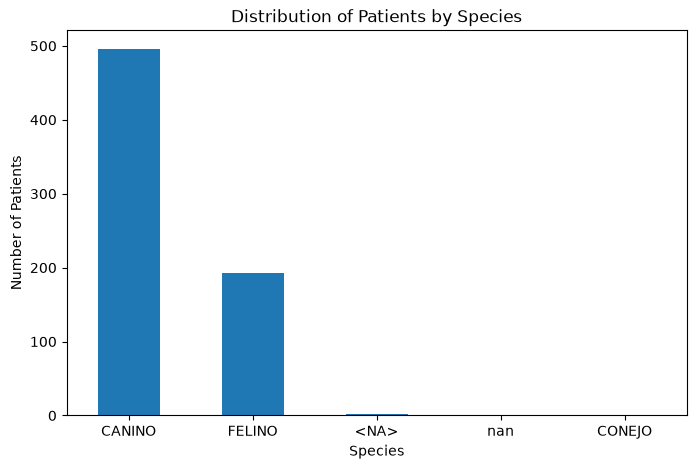

In [197]:
# ==========================================
# BAR CHART
# ==========================================

import matplotlib.pyplot as plt

species_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Patients by Species")

plt.xlabel("Species")

plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

plt.show()

# Conclusions

The data cleaning process significantly improved the quality and consistency of the veterinary radiology dataset.

## Main cleaning tasks completed

- Standardized species names.
- Standardized breeds.
- Standardized patient sex values.
- Cleaned sterilization status.
- Converted weight values to numeric format.
- Corrected and standardized birth dates.
- Corrected examination dates.
- Cleaned the number of radiographs.
- Standardized medical report information.
- Cleaned owner contact information.
- Removed completely empty records.
- Preserved original values in backup columns for traceability.

## Final dataset

- Records: **693**
- Variables: **24**
- Duplicate rows: **0**

The resulting dataset is now consistent, well documented, and suitable for exploratory data analysis and dashboard development.

The next stage of the project is **Exploratory Data Analysis (EDA)**, where the cleaned dataset will be analyzed to identify trends, distributions, and patterns in veterinary radiology services.

In [198]:
# ==========================================
# SAVE CLEAN DATASET
# ==========================================

radiology_clean.to_csv(
    "../data/processed/radiology_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!
